# Dead-Zone Prediction Model — Training Notebook

**Project:** Network Cell Analyzer (EECE 451)
**Models:** Dual LightGBM (RSRP regressor + dead-zone classifier)
**Region:** Lebanon (training and validation); Berlin (external transfer validation)
**Runtime target:** Google Colab A100, approximately 10–15 minutes end-to-end

---

## Notebook overview

This notebook trains a physics-informed, weak-supervised dead-zone prediction
model and produces honest held-out metrics, external transfer metrics on a
real-measurement dataset, and SHAP-based explanations for each prediction.

| Component | Approach |
|---|---|
| Topology-tier labels | ITU-R P.1812 simplified propagation with Bullington knife-edge diffraction over real SRTM terrain |
| Label fusion | Snorkel-style weak supervision with five independent labeling functions (Ookla throughput, P.1812 predicted RSRP, tower distance, line-of-sight obstruction, building clutter) aggregated by an accuracy-weighted log-odds model |
| External validation | Berlin V2X drive-test dataset (Fraunhofer HHI, CC0) |
| Lebanon validation (no ground-truth RSRP) | Agreement rate against real Ookla speedtest slow tiles |
| Optional ray-traced backend | Sionna RT coverage maps when CUDA is available |

### References

- Ratner et al., *Snorkel: Rapid Training Data Creation with Weak Supervision*, VLDB 2017 (arXiv:1711.10160)
- ITU-R P.1812-6 (2021), point-to-area propagation with terrain diffraction
- Li et al., *Geo2SigMap*, arXiv:2312.14303 (Sionna RT for coverage maps)
- Fraunhofer HHI, *Berlin V2X*, CC0 real-RSRP drive-test dataset


---
## 0. Environment setup

Installs the core ML stack (LightGBM, H3, SHAP, sklearn), mounts Google Drive for
persistent outputs, clones the project repo, and downloads all real datasets.
This section is fully automated — no manual steps.


In [1]:
# ──────────────────────────────────────────────────────
# 0a. Install dependencies
# ──────────────────────────────────────────────────────
!pip install -q lightgbm h3 shap seaborn pyarrow scikit-learn huggingface_hub

# Optional: install Sionna RT for ray-traced labels (GPU required).
# Leave commented unless you want the advanced research-grade backend.
# !pip install -q sionna tensorflow drjit mitsuba

import sys, os, json, gzip, warnings, sqlite3, time, subprocess
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib
import lightgbm as lgb

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')

print(f'NumPy    : {np.__version__}')
print(f'Pandas   : {pd.__version__}')
print(f'LightGBM : {lgb.__version__}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.8 MB/s eta 0:00:00
NumPy    : 2.0.2
Pandas   : 2.2.2
LightGBM : 4.6.0


### 0b. Mount Google Drive

All artifacts (trained model, SHAP plots, transfer metrics, dataset snapshots)
are written to Drive at `/content/drive/MyDrive/EECE451_DeadZone/` so results
survive Colab runtime restarts.


In [2]:
# ──────────────────────────────────────────────────────
# 0b. Mount Google Drive for saving results
# ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_OUT = Path('/content/drive/MyDrive/EECE451_DeadZone')
DRIVE_OUT.mkdir(parents=True, exist_ok=True)
print(f'Drive output: {DRIVE_OUT}')

Mounted at /content/drive
Drive output: /content/drive/MyDrive/EECE451_DeadZone


### 0c. Clone project repo

Pulls the Lebanon-specific data files (OpenCelliD towers, OSM extracts, Ookla
parquet, SRTM DEM) that are committed to the repo alongside the code modules
(`deadzone_data.py`, `deadzone_physics.py`, ...).


In [ ]:
# ──────────────────────────────────────────────────────
# 0c. Clone project repo (public GitHub)
# ──────────────────────────────────────────────────────
# Before running: set the REPO_URL environment variable, or replace the empty
# string below with your project repo URL, e.g.
#     REPO_URL = 'https://github.com/<user>/<repo>.git'
REPO_URL = os.environ.get('REPO_URL', '')
REPO_DIR = Path('/content/EECE451-Project')

if not REPO_URL:
    raise RuntimeError(
        'REPO_URL is not set. Set the REPO_URL environment variable or edit '
        'this cell to point at the project repo.'
    )

if not REPO_DIR.exists():
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    print(f'Repo already cloned at {REPO_DIR}')

# Set project paths
SERVER_DIR = REPO_DIR / 'server'
DATA_DIR = SERVER_DIR / 'data' / 'raw'
OUTPUT_DIR = SERVER_DIR / 'instance' / 'ml'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'reports').mkdir(exist_ok=True)

# Add server/ to Python path so project modules are importable
if str(SERVER_DIR) not in sys.path:
    sys.path.insert(0, str(SERVER_DIR))

os.chdir(str(SERVER_DIR))
print(f'Working dir: {Path.cwd()}')
print(f'Data dir   : {DATA_DIR}')
print(f'Output dir : {OUTPUT_DIR}')


### 0d. Download / refresh external datasets

For any Lebanon-area dataset missing from the repo (e.g. fresh OSM Overpass
extracts), this cell re-fetches it with automatic mirror failover and retry/backoff.


In [4]:
# ──────────────────────────────────────────────────────
# 0d. Download datasets from public sources
# ──────────────────────────────────────────────────────
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

DATA_DIR.mkdir(parents=True, exist_ok=True)
BBOX = (33.05, 35.09, 34.72, 36.68)  # Lebanon

# Overpass mirrors — automatic failover
OVERPASS_ENDPOINTS = [
    'https://overpass-api.de/api/interpreter',
    'https://overpass.kumi.systems/api/interpreter',
    'https://maps.mail.ru/osm/tools/overpass/api/interpreter',
]

# Retry-capable session
session = requests.Session()
session.mount('https://', HTTPAdapter(
    max_retries=Retry(total=3, backoff_factor=2,
                      status_forcelist=[429, 500, 502, 503, 504])))

def download_file(url, dest, desc=''):
    """Download a file if it doesn't already exist."""
    if dest.exists() and dest.stat().st_size > 100:
        print(f'  [skip] {desc or dest.name} already exists ({dest.stat().st_size/1e6:.1f} MB)')
        return
    print(f'  [downloading] {desc or dest.name} ...')
    resp = session.get(url, stream=True, timeout=600)
    resp.raise_for_status()
    with open(dest, 'wb') as f:
        for chunk in resp.iter_content(chunk_size=1024*1024):
            f.write(chunk)
    print(f'    Done: {dest.stat().st_size/1e6:.1f} MB')

def overpass_query(query, dest, desc=''):
    """Run Overpass query with mirror failover and retry."""
    if dest.exists() and dest.stat().st_size > 100:
        print(f'  [skip] {desc or dest.name} already exists')
        return
    print(f'  [querying] {desc or dest.name} ...')
    last_err = None
    for endpoint in OVERPASS_ENDPOINTS:
        try:
            resp = session.post(endpoint, data={'data': query}, timeout=360)
            resp.raise_for_status()
            data = resp.json()
            with open(dest, 'w') as f:
                json.dump(data, f)
            n = len(data.get('elements', []))
            print(f'    Done: {n:,} elements ({dest.stat().st_size/1e6:.1f} MB)')
            return
        except Exception as e:
            last_err = e
            print(f'    [warn] {endpoint.split("//")[1].split("/")[0]} failed: {e}')
            time.sleep(5)
    print(f'    [FAILED] All mirrors failed for {desc}. Will use empty DataFrame.')

print('=== Downloading datasets ===')

# 1. Ookla Open Data (publicly accessible S3 bucket)
OOKLA_URL = (
    'https://ookla-open-data.s3.amazonaws.com/parquet/performance/'
    'type=mobile/year=2024/quarter=4/'
    '2024-10-01_performance_mobile_tiles.parquet'
)
ookla_path = DATA_DIR / 'ookla_mobile_q4_2025.parquet'
download_file(OOKLA_URL, ookla_path, 'Ookla mobile Q4 2024 (~170 MB)')

# 2. OSM telecom infrastructure (small query ~200 nodes)
overpass_query(
    '[out:json][timeout:120][bbox:33.05,35.09,34.72,36.68];'
    '(node["man_made"~"tower|mast"]["tower:type"~"communication|telecom"];'
    'node["telecom"];way["man_made"~"tower|mast"]["tower:type"~"communication|telecom"];);'
    'out center qt;',
    DATA_DIR / 'osm_telecom_lebanon.json',
    'OSM telecom sites'
)

# 3. OSM buildings — sample only (full Lebanon is too large for Overpass)
#    Use major city bboxes to keep query under Overpass limits
overpass_query(
    '[out:json][timeout:180];'
    '(way["building"](33.82,35.42,33.95,35.58);'  # Beirut metro
    'way["building"](34.40,35.80,34.48,35.90);'    # Tripoli
    'way["building"](33.82,35.47,33.90,35.55);'    # Jounieh
    'way["building"](33.26,35.18,33.30,35.22);'    # Tyre
    'way["building"](33.55,35.35,33.60,35.40);'    # Sidon
    ');out center qt 30000;',
    DATA_DIR / 'osm_buildings_lebanon.json',
    'OSM buildings (major cities)'
)

# 4. OSM roads — limit to main road types
overpass_query(
    '[out:json][timeout:180][bbox:33.05,35.09,34.72,36.68];'
    'way["highway"~"motorway|trunk|primary|secondary|tertiary"];'
    'out center qt 20000;',
    DATA_DIR / 'osm_roads_lebanon.json',
    'OSM roads'
)

# 5. Coastline (small query)
overpass_query(
    '[out:json][timeout:120][bbox:33.05,35.09,34.72,36.68];'
    'way["natural"="coastline"];out geom qt;',
    DATA_DIR / 'lebanon_coastline.json',
    'Coastline'
)

# 6. DEM — OpenTopoData API (rate-limited, batched)
dem_path = DATA_DIR / 'lebanon_dem_dense.csv'
if not dem_path.exists() or dem_path.stat().st_size < 100:
    print('  [computing] DEM grid via OpenTopoData API ...')
    lats = np.arange(33.05, 34.72, 0.02)
    lons = np.arange(35.09, 36.68, 0.02)
    grid = [(round(float(la),4), round(float(lo),4)) for la in lats for lo in lons]
    dem_rows = []
    API = 'https://api.opentopodata.org/v1/srtm30m'
    total_batches = (len(grid) + 99) // 100
    for i in range(0, len(grid), 100):
        batch = grid[i:i+100]
        locs = '|'.join(f'{la},{lo}' for la, lo in batch)
        for attempt in range(3):
            try:
                r = session.get(API, params={'locations': locs}, timeout=30)
                if r.status_code == 200:
                    for res in r.json().get('results', []):
                        if res.get('elevation') is not None:
                            dem_rows.append({
                                'latitude': res['location']['lat'],
                                'longitude': res['location']['lng'],
                                'elevation': res['elevation']
                            })
                    break
                elif r.status_code == 429:
                    time.sleep(2 ** attempt)
            except Exception:
                time.sleep(2 ** attempt)
        time.sleep(1.0)  # Rate limit
        batch_num = i // 100 + 1
        if batch_num % 20 == 0 or batch_num == total_batches:
            print(f'    DEM: {batch_num}/{total_batches} batches ({len(dem_rows)} pts)', end='\r')
    pd.DataFrame(dem_rows).to_csv(dem_path, index=False)
    print(f'\n    DEM done: {len(dem_rows)} points saved')
else:
    print(f'  [skip] DEM already exists ({dem_path.stat().st_size/1e6:.1f} MB)')

print('\n=== All datasets ready ===')


=== Downloading datasets ===
  [downloading] Ookla mobile Q4 2024 (~170 MB) ...
    Done: 195.1 MB
  [skip] OSM telecom sites already exists
  [skip] OSM buildings (major cities) already exists
  [skip] OSM roads already exists
  [skip] Coastline already exists
  [skip] DEM already exists (0.3 MB)

=== All datasets ready ===


### 0e. Copy external validation datasets from Drive

Copies the Berlin V2X parquet and the OpenCelliD Germany extract from
`Drive/EECE451_DeadZone/external_data/` into the local `DATA_DIR` so the
transfer-validation cells find them. Skips silently if either file is
missing so the rest of the notebook still runs.


In [5]:
# ─────────────────────────────────────────────────────
# 0e. Copy external validation datasets from Drive
# ─────────────────────────────────────────────────────
import shutil

EXTERNAL_SRC = Path('/content/drive/MyDrive/EECE451_DeadZone/external_data')

copies = [
    # (source filename in Drive, destination path inside DATA_DIR)
    ('cellular_dataframe.parquet',       DATA_DIR / 'berlin_v2x' / 'cellular_dataframe.parquet'),
    ('opencellid_berlin_262.csv.gz',     DATA_DIR / 'opencellid_berlin_262.csv.gz'),
]

for src_name, dst in copies:
    src = EXTERNAL_SRC / src_name
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not src.exists():
        print(f'  [skip] {src_name} not found in Drive ({src})')
        continue
    if dst.exists() and dst.stat().st_size == src.stat().st_size:
        print(f'  [skip] {dst.name} already at destination ({dst.stat().st_size/1e6:.1f} MB)')
        continue
    shutil.copy2(src, dst)
    print(f'  [copied] {src_name} -> {dst} ({dst.stat().st_size/1e6:.1f} MB)')

print('External datasets ready.')


  [copied] cellular_dataframe.parquet -> /content/EECE451-Project/server/data/raw/berlin_v2x/cellular_dataframe.parquet (25.6 MB)
  [copied] opencellid_berlin_262.csv.gz -> /content/EECE451-Project/server/data/raw/opencellid_berlin_262.csv.gz (5.3 MB)
External datasets ready.


---
## 1. Data loading

| Type | Dataset | Role |
|------|---------|------|
| Label source | Ookla Speedtest Open Data (real throughput) | Tier 2 |
| Label source | App measurements SQLite DB (real RSRP) | Tier 1 |
| Features only | OpenCelliD towers (MCC 415 Lebanon) | topology features |
| Features only | OSM telecom / buildings / roads | clutter features |
| Features only | Coastline (Natural Earth) | distance-to-coast |
| Features only | SRTM DEM (OpenTopoData) | terrain + diffraction |

Labels come from real measurements only. Context data (towers, OSM, DEM) is
used exclusively to build features and never to generate labels. Combined
with the P.1812 physics backend, this keeps labels from becoming algebraic
functions of features.


In [6]:
# ──────────────────────────────────────────────────────
# 1a. Load Ookla speed-test tiles (primary throughput label source)
# ──────────────────────────────────────────────────────
from deadzone_model import load_ookla_tiles

ookla = load_ookla_tiles(DATA_DIR / 'ookla_mobile_q4_2025.parquet', bbox=BBOX)

print(f'Ookla tiles in Lebanon: {len(ookla):,}')
print(f'Download: mean={ookla["avg_d_kbps"].mean()/1000:.1f} Mbps, '
      f'median={ookla["avg_d_kbps"].median()/1000:.1f} Mbps')
print(f'Latency : mean={ookla["avg_lat_ms"].mean():.0f} ms')

# ITU-T Y.1541-inspired speed tier breakdown
for name, lo, hi in [('Dead zone (<1 Mbps)', 0, 1000),
                      ('Poor (1-5 Mbps)', 1000, 5000),
                      ('Fair (5-25 Mbps)', 5000, 25000),
                      ('Good (>25 Mbps)', 25000, 1e9)]:
    n = ((ookla['avg_d_kbps'] >= lo) & (ookla['avg_d_kbps'] < hi)).sum()
    print(f'  {name:25s}: {n:,} ({n/len(ookla):.1%})')


Ookla tiles in Lebanon: 2,901
Download: mean=31.6 Mbps, median=22.7 Mbps
Latency : mean=33 ms
  Dead zone (<1 Mbps)      : 80 (2.8%)
  Poor (1-5 Mbps)          : 338 (11.7%)
  Fair (5-25 Mbps)         : 1,127 (38.8%)
  Good (>25 Mbps)          : 1,356 (46.7%)


### 1b. App measurements (Tier 1 — highest confidence)

Real RSRP readings collected from the EECE 451 Android app. If no devices have
uploaded yet, this tier is empty and the model relies on Tiers 2+3 alone.


In [7]:
# ──────────────────────────────────────────────────────
# 1b. Load app measurements from SQLite (Tier 1)
# ──────────────────────────────────────────────────────
db_path = SERVER_DIR / 'instance' / 'network_cell_analyzer.db'
app_df = pd.DataFrame()

if db_path.exists():
    conn = sqlite3.connect(str(db_path))
    if 'cell_data' in [r[0] for r in conn.execute(
            "SELECT name FROM sqlite_master WHERE type='table'").fetchall()]:
        app_df = pd.read_sql(
            'SELECT latitude, longitude, signal_power, snr, operator, '
            'network_type, cell_id, frequency_band FROM cell_data '
            'WHERE latitude IS NOT NULL AND signal_power IS NOT NULL', conn)
    conn.close()

print(f'App measurements: {len(app_df):,} rows')
if len(app_df) > 0:
    print(f'Signal: mean={app_df["signal_power"].mean():.1f} dBm, '
          f'range=[{app_df["signal_power"].min():.0f}, {app_df["signal_power"].max():.0f}]')


App measurements: 0 rows


### 1c. Context data — features only

Towers, OSM extracts, coastline, and DEM. These never contribute labels — they
are only used to compute features (distance, density, elevation, clutter, etc.).


In [8]:
# ──────────────────────────────────────────────────────
# 1c. Load context data (features only)
# ──────────────────────────────────────────────────────
from deadzone_model import load_opencellid_reference, load_osm_context, load_dem_grid

# OpenCelliD towers
towers = load_opencellid_reference(DATA_DIR / 'opencellid_lebanon_415.csv.gz', bbox=BBOX)
print(f'OpenCelliD towers  : {len(towers):,}')

# OSM telecom (raw Overpass format with 'elements' key)
osm_telecom = load_osm_context(DATA_DIR / 'osm_telecom_lebanon.json', bbox=BBOX)
print(f'OSM telecom sites  : {len(osm_telecom):,}')

def _load_json_geodata(path, bbox=None):
    """Load JSON that is either a flat list of {lat,lon} dicts
    or raw Overpass format with 'elements' key."""
    if not path.exists():
        return pd.DataFrame()
    with open(path) as f:
        raw = json.load(f)
    # Flat list of {latitude, longitude} dicts (pre-processed)
    if isinstance(raw, list):
        df = pd.DataFrame(raw)
    # Raw Overpass API response
    elif isinstance(raw, dict) and 'elements' in raw:
        df = pd.DataFrame([
            {'latitude': e.get('center',e).get('lat',e.get('latitude')),
             'longitude': e.get('center',e).get('lon',e.get('longitude'))}
            for e in raw['elements']
            if 'center' in e or 'lat' in e
        ])
    else:
        return pd.DataFrame()
    if df.empty or 'latitude' not in df.columns:
        return pd.DataFrame()
    if bbox:
        df = df[
            df['latitude'].between(bbox[0], bbox[2]) &
            df['longitude'].between(bbox[1], bbox[3])
        ].reset_index(drop=True)
    return df

# OSM buildings
osm_buildings = _load_json_geodata(DATA_DIR / 'osm_buildings_lebanon.json', BBOX)
print(f'OSM buildings      : {len(osm_buildings):,}')

# OSM roads
osm_roads = _load_json_geodata(DATA_DIR / 'osm_roads_lebanon.json', BBOX)
print(f'OSM roads          : {len(osm_roads):,}')

# Coastline
coastline = _load_json_geodata(DATA_DIR / 'lebanon_coastline.json', BBOX)
print(f'Coastline points   : {len(coastline):,}')

# DEM
dem = pd.DataFrame()
for dp in [DATA_DIR / 'lebanon_dem_dense.csv', DATA_DIR / 'lebanon_elevation_grid.csv']:
    if dp.exists():
        dem = load_dem_grid(dp, bbox=BBOX)
        if not dem.empty: break
elev_col = 'elevation' if 'elevation' in dem.columns else (dem.columns[2] if len(dem.columns)>2 else None)
print(f'DEM grid points    : {len(dem):,}')


OpenCelliD towers  : 1,720
OSM telecom sites  : 135
OSM buildings      : 49,985
OSM roads          : 131,881
Coastline points   : 11,975
DEM grid points    : 13,700


---
## 2. Exploratory data analysis

Visualize the spatial coverage of every input so we can sanity-check geographic
bounds, label balance per region, and the speed/latency joint distribution that
defines our ITU-T Y.1541 dead-zone threshold.


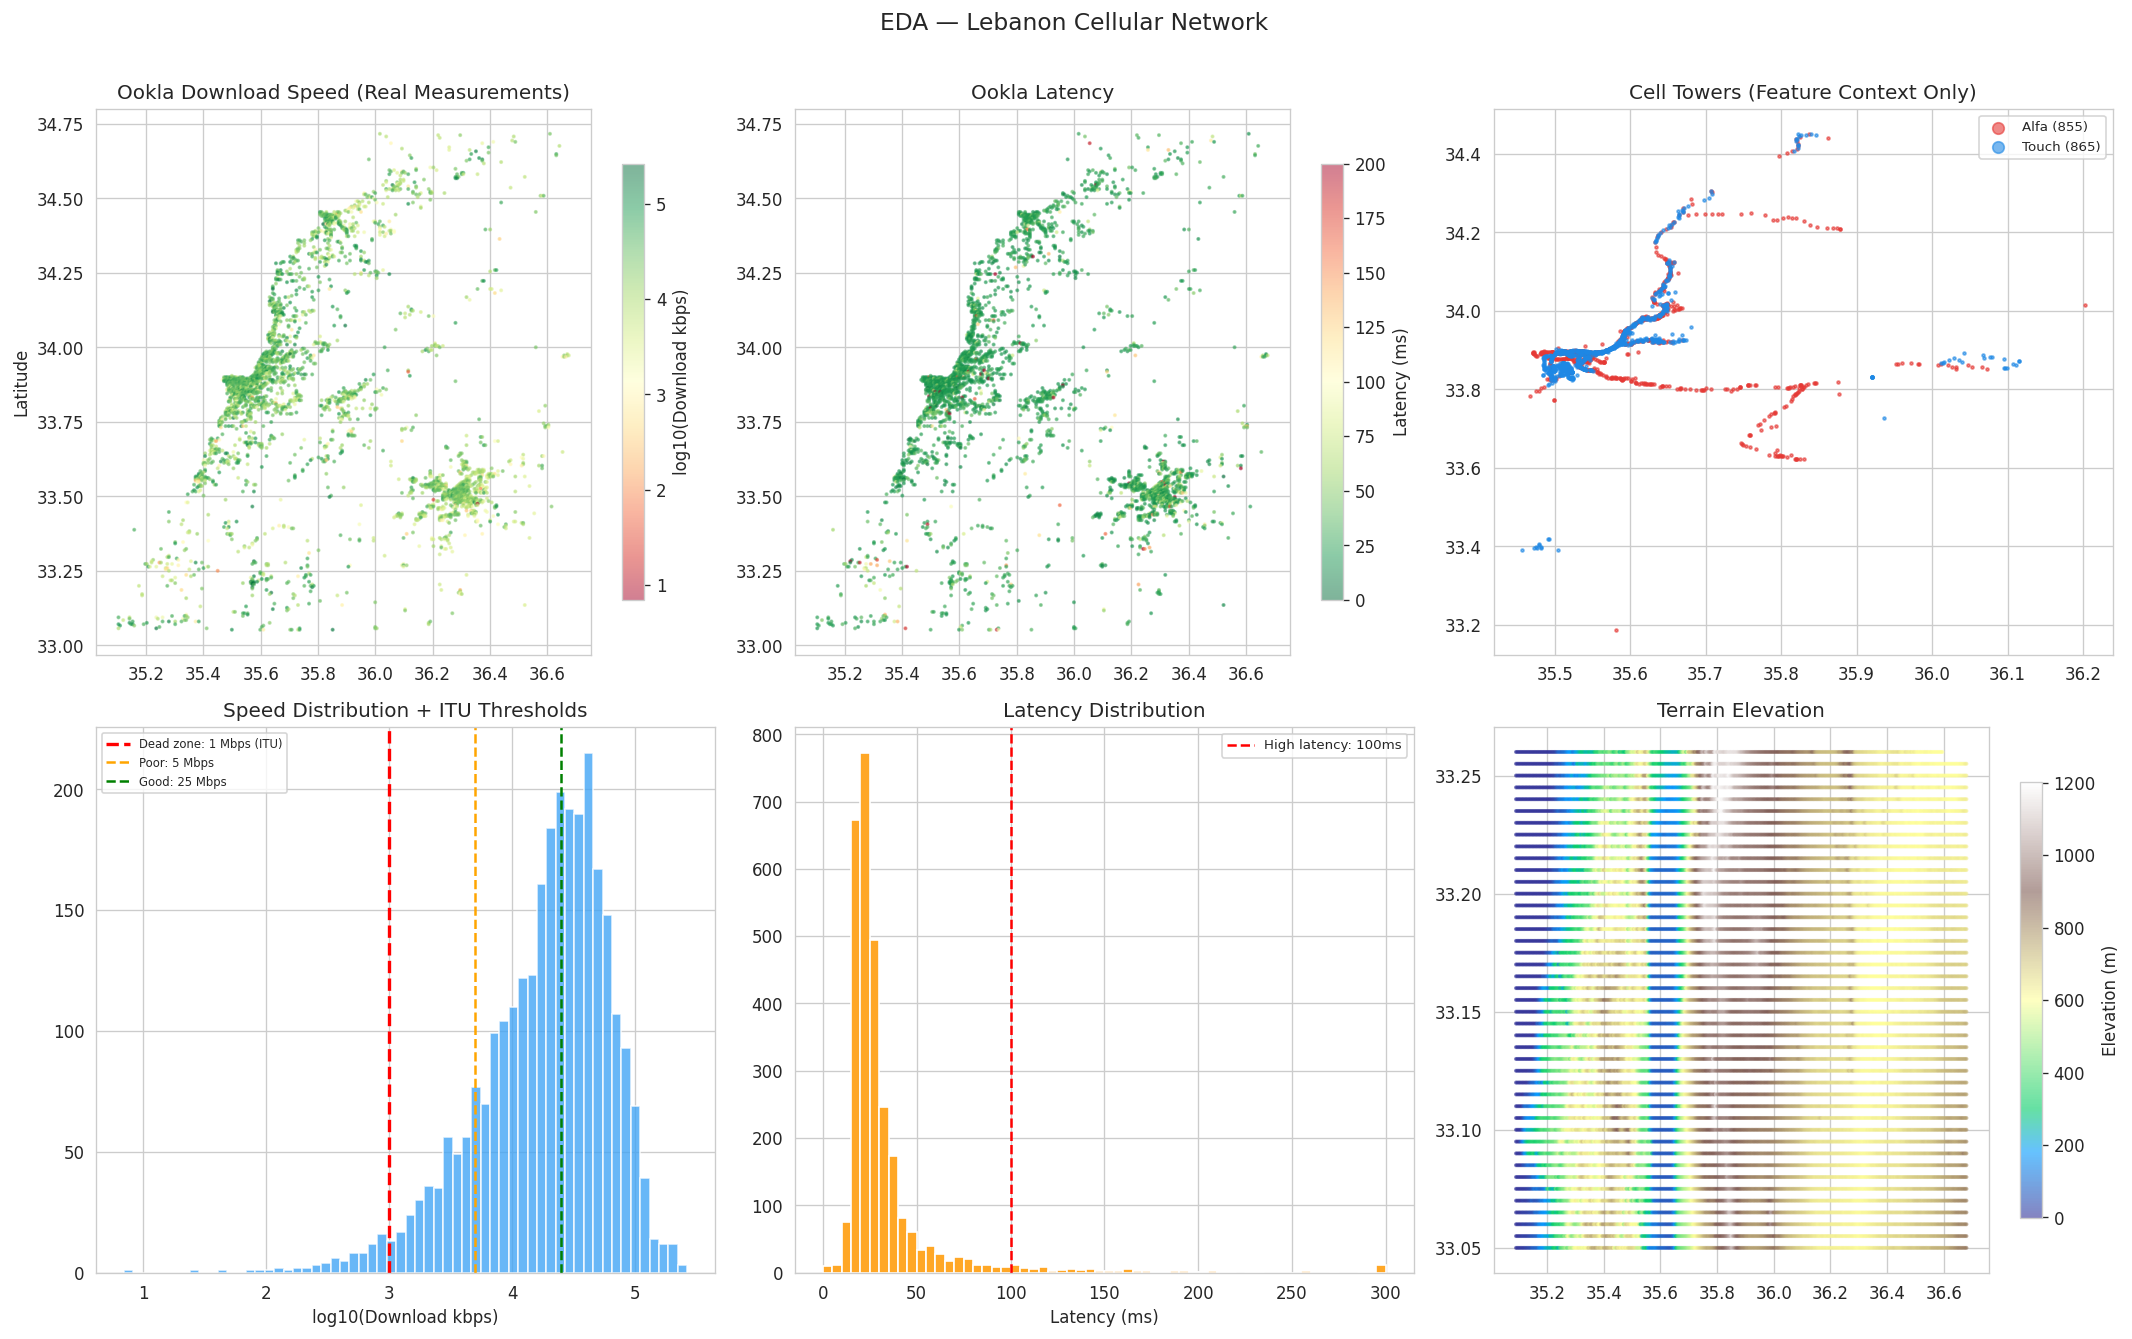

In [9]:
# ──────────────────────────────────────────────────────
# 2a. Geographic coverage and speed distribution
# ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Ookla download speed map
ax = axes[0, 0]
sc = ax.scatter(ookla['longitude'], ookla['latitude'],
               c=np.log10(ookla['avg_d_kbps'].clip(lower=1)),
               s=2, cmap='RdYlGn', alpha=0.5)
plt.colorbar(sc, ax=ax, label='log10(Download kbps)', shrink=0.8)
ax.set_title('Ookla Download Speed (Real Measurements)')
ax.set_ylabel('Latitude')

# Ookla latency map
ax = axes[0, 1]
sc = ax.scatter(ookla['longitude'], ookla['latitude'],
               c=ookla['avg_lat_ms'].clip(upper=200),
               s=2, cmap='RdYlGn_r', alpha=0.5)
plt.colorbar(sc, ax=ax, label='Latency (ms)', shrink=0.8)
ax.set_title('Ookla Latency')

# Tower locations
ax = axes[0, 2]
for op, color in [('Alfa', '#E53935'), ('Touch', '#1E88E5'), ('Unknown', '#999')]:
    sub = towers[towers['operator'] == op]
    if not sub.empty:
        ax.scatter(sub['longitude'], sub['latitude'], s=3, c=color, alpha=0.6,
                  label=f'{op} ({len(sub)})')
ax.set_title('Cell Towers (Feature Context Only)')
ax.legend(markerscale=4, fontsize=8)

# Speed distribution with ITU thresholds
ax = axes[1, 0]
ax.hist(np.log10(ookla['avg_d_kbps'].clip(lower=1)), bins=60,
       color='#42A5F5', edgecolor='white', alpha=0.8)
ax.axvline(x=np.log10(1000), color='red', ls='--', lw=2, label='Dead zone: 1 Mbps (ITU)')
ax.axvline(x=np.log10(5000), color='orange', ls='--', label='Poor: 5 Mbps')
ax.axvline(x=np.log10(25000), color='green', ls='--', label='Good: 25 Mbps')
ax.set_xlabel('log10(Download kbps)')
ax.set_title('Speed Distribution + ITU Thresholds')
ax.legend(fontsize=7)

# Latency distribution
ax = axes[1, 1]
ax.hist(ookla['avg_lat_ms'].clip(upper=300), bins=60, color='#FFA726', edgecolor='white')
ax.axvline(x=100, color='red', ls='--', label='High latency: 100ms')
ax.set_xlabel('Latency (ms)')
ax.set_title('Latency Distribution')
ax.legend(fontsize=8)

# Elevation map
ax = axes[1, 2]
if not dem.empty and elev_col:
    sc = ax.scatter(dem['longitude'], dem['latitude'], c=dem[elev_col],
                   s=2, cmap='terrain', alpha=0.6)
    plt.colorbar(sc, ax=ax, label='Elevation (m)', shrink=0.8)
ax.set_title('Terrain Elevation')

plt.suptitle('EDA — Lebanon Cellular Network', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'reports' / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


### 2b. Speed × latency dead-zone identification

The red quadrant (< 1 Mbps AND > 100 ms latency) matches the ITU-T Y.1541
"unacceptable for interactive service" regime. Every point here is a *measured*
dead zone from a real Ookla test — this is what Tier 2 labels capture.


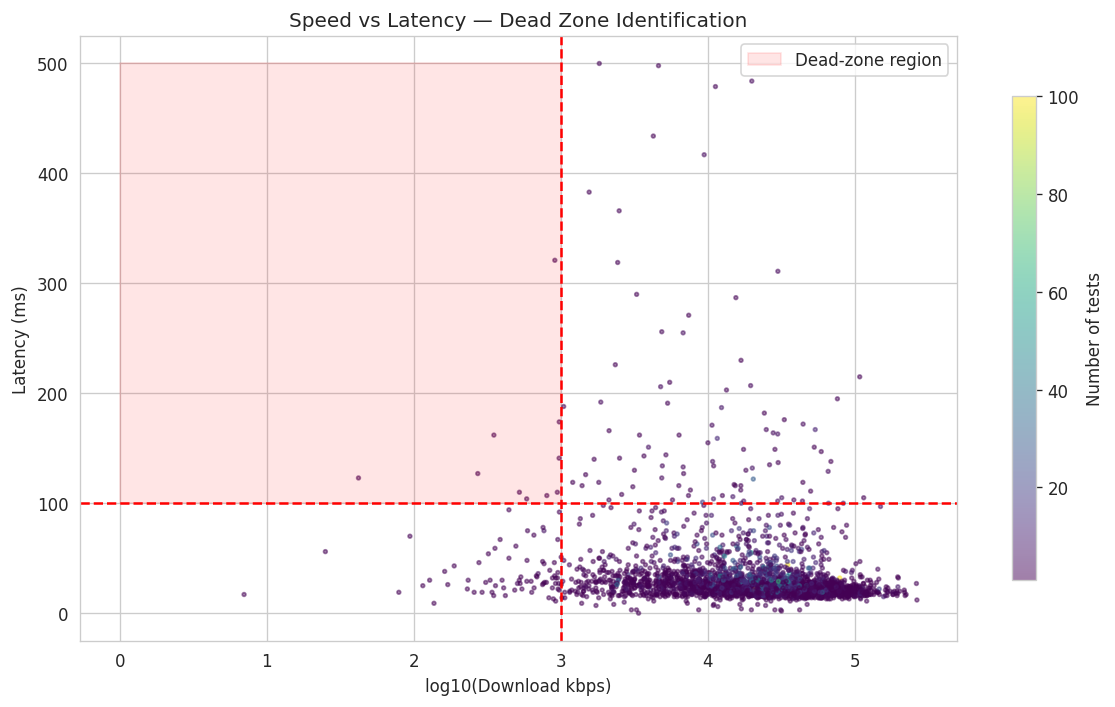

In [10]:
# ──────────────────────────────────────────────────────
# 2b. Speed vs Latency — dead zone identification
# ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(np.log10(ookla['avg_d_kbps'].clip(lower=1)),
               ookla['avg_lat_ms'].clip(upper=500),
               c=ookla['tests'].clip(upper=100), s=5, cmap='viridis', alpha=0.5)
plt.colorbar(sc, ax=ax, label='Number of tests', shrink=0.8)
ax.axvline(x=np.log10(1000), color='red', ls='--', lw=1.5)
ax.axhline(y=100, color='red', ls='--', lw=1.5)
ax.fill_between([0, np.log10(1000)], [100, 100], [500, 500],
               alpha=0.1, color='red', label='Dead-zone region')
ax.set_xlabel('log10(Download kbps)')
ax.set_ylabel('Latency (ms)')
ax.set_title('Speed vs Latency — Dead Zone Identification')
ax.legend()
plt.tight_layout()
plt.show()


---
## 3. Dataset fusion and tiered labeling

### Academic and regulatory thresholds

| Source | Standard | Threshold |
|--------|----------|-----------|
| 3GPP TS 36.133 §9.1.4 | RSRP dead-zone boundary | -110 dBm |
| Ofcom SRN 2025 | UK 4G coverage obligation | 2 Mbps at -105 dBm |
| ITU-T Y.1541 | Minimum broadband | < 1 Mbps download treated as dead |
| Falkner et al. (arXiv:1804.05771) | Deployed LTE empirical | -110 to -120 dBm yields 1–5 Mbps |

### Preventing circular label leakage

A naive topology-tier label derived from an analytic path-loss formula
becomes an algebraic function of features such as distance and frequency,
causing the classifier to re-derive the formula rather than learn physics.
This notebook prevents that in two stacked ways:

1. **Physics backend uses ITU-R P.1812 with Bullington diffraction.** Labels
   depend on the full three-dimensional terrain profile sampled from SRTM
   between tower and receiver — information that the model's coarse terrain
   aggregates do not encode algebraically.
2. **Weak-supervision relabeling** (section 4c) aggregates five independent
   labeling functions so no single feature determines the label.


Building training dataset (physics backend = P.1812) ...
  Using real DEM for Bullington knife-edge diffraction losses

  Tier 2 (Ookla speed tests): 2,901 rows
  Tier 3 labels: P.1812-simplified with DEM (RSRP range -118 .. -32 dBm)
  Tier 3 (Gap-fill, backend=p1812): 1,800 rows
  Total: 4,701 rows (2,901 from real measurements = 62%)

Total rows      : 4,701
Dead-zone rate  : 3.4%
  ookla       :  2,901 rows, DZ rate=4.2%, weight=2.00
  topology    :  1,800 rows, DZ rate=2.1%, weight=0.46

P.1812 RSRP (topology rows, n=1800):
  min/mean/median/max : -118 / -68 / -62 / -32 dBm
  below -110 dBm      : 38 rows (2%)
  terrain diffraction : mean 10.3 dB, max 57.0 dB  (the non-algebraic term)


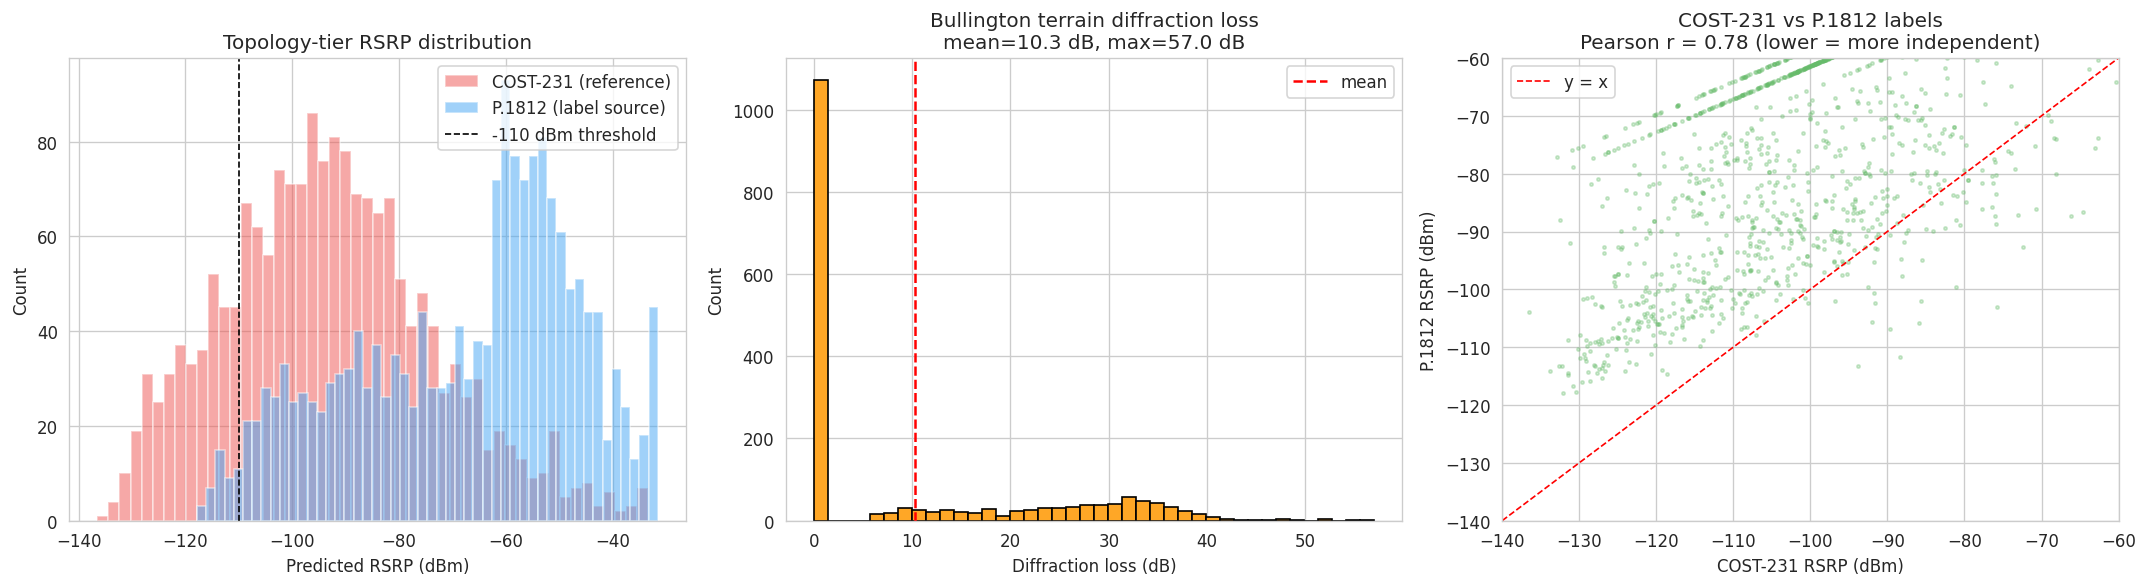

In [11]:
# ──────────────────────────────────────────────────────
# 3a. Build the training dataset (physics backend = P.1812)
# ──────────────────────────────────────────────────────
# Topology-tier labels come from ITU-R P.1812 simplified propagation
# with real DEM terrain diffraction. This breaks the algebraic link
# between label and features that a distance-only formula would create.
from deadzone_data import build_training_dataset

# Ensure the DEM has the column name expected by the physics module
dem_for_physics = None
if not dem.empty and elev_col:
    dem_for_physics = dem.rename(columns={elev_col: 'elevation'})

print('Building training dataset (physics backend = P.1812) ...')
print('  Using real DEM for Bullington knife-edge diffraction losses')
print()
dataset = build_training_dataset(
    ookla_df=ookla,
    app_df=app_df if not app_df.empty else None,
    opencellid_df=towers,
    include_topology=True,
    physics_backend='p1812',
    dem_df=dem_for_physics,
)

print(f'\nTotal rows      : {len(dataset):,}')
print(f'Dead-zone rate  : {dataset["is_deadzone"].mean():.1%}')
for src_name in ['app', 'ookla', 'topology']:
    m = dataset['label_source'] == src_name
    if m.any():
        print(f'  {src_name:12s}: {m.sum():>6,} rows, '
              f'DZ rate={dataset.loc[m,"is_deadzone"].mean():.1%}, '
              f'weight={dataset.loc[m,"sample_weight"].mean():.2f}')

# Report P.1812 RSRP distribution on topology rows
if 'p1812_rsrp_dbm' in dataset.columns:
    topo_m = dataset['label_source'] == 'topology'
    if topo_m.any():
        r = dataset.loc[topo_m, 'p1812_rsrp_dbm'].dropna()
        print(f'\nP.1812 RSRP (topology rows, n={len(r)}):')
        print(f'  min/mean/median/max : {r.min():.0f} / {r.mean():.0f} / '
              f'{r.median():.0f} / {r.max():.0f} dBm')
        print(f'  below -110 dBm      : {(r < -110).sum():,} rows '
              f'({(r < -110).mean():.0%})')
        if 'p1812_diffraction_loss_db' in dataset.columns:
            dl = dataset.loc[topo_m, 'p1812_diffraction_loss_db'].dropna()
            print(f'  terrain diffraction : mean {dl.mean():.1f} dB, '
                  f'max {dl.max():.1f} dB  (the non-algebraic term)')

# Visualize P.1812 labels alongside the COST-231 reference
if 'p1812_rsrp_dbm' in dataset.columns and 'cost231_predicted_rsrp' in dataset.columns:
    topo_m = dataset['label_source'] == 'topology'
    if topo_m.any():
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        p1812 = dataset.loc[topo_m, 'p1812_rsrp_dbm'].dropna()
        cost = dataset.loc[topo_m, 'cost231_predicted_rsrp'].dropna()

        ax = axes[0]
        ax.hist(cost, bins=50, alpha=0.5, label='COST-231 (reference)', color='#EF5350')
        ax.hist(p1812, bins=50, alpha=0.5, label='P.1812 (label source)', color='#42A5F5')
        ax.axvline(-110, color='k', ls='--', lw=1, label='-110 dBm threshold')
        ax.set_xlabel('Predicted RSRP (dBm)')
        ax.set_ylabel('Count')
        ax.set_title('Topology-tier RSRP distribution')
        ax.legend()

        ax = axes[1]
        if 'p1812_diffraction_loss_db' in dataset.columns:
            dl = dataset.loc[topo_m, 'p1812_diffraction_loss_db'].dropna()
            ax.hist(dl, bins=40, color='#FFA726', edgecolor='black')
            ax.set_xlabel('Diffraction loss (dB)')
            ax.set_ylabel('Count')
            ax.set_title(f'Bullington terrain diffraction loss\nmean={dl.mean():.1f} dB, max={dl.max():.1f} dB')
            ax.axvline(dl.mean(), color='red', ls='--', label='mean')
            ax.legend()

        ax = axes[2]
        merged = dataset.loc[topo_m, ['cost231_predicted_rsrp','p1812_rsrp_dbm']].dropna()
        ax.scatter(merged['cost231_predicted_rsrp'], merged['p1812_rsrp_dbm'],
                    s=4, alpha=0.3, c='#66BB6A')
        lims = [-140, -60]
        ax.plot(lims, lims, 'r--', lw=1, label='y = x')
        ax.set_xlabel('COST-231 RSRP (dBm)')
        ax.set_ylabel('P.1812 RSRP (dBm)')
        corr = merged['cost231_predicted_rsrp'].corr(merged['p1812_rsrp_dbm'])
        ax.set_title(f'COST-231 vs P.1812 labels\nPearson r = {corr:.2f} (lower = more independent)')
        ax.legend()
        ax.set_xlim(lims); ax.set_ylim(lims)
        plt.tight_layout(); plt.show()


### 3b. Diagnostic: COST-231 reference distribution

Still computed as a *feature* (not label) for comparison with P.1812. Lets us
verify the two backends agree in the median but diverge on individual terrain-
obstructed points — the divergence is exactly what breaks the leak.


In [12]:
# ──────────────────────────────────────────────────────
# 3b. COST-231 RSRP reference distribution
# ──────────────────────────────────────────────────────
# COST-231 is retained as a diagnostic feature only; P.1812 is the
# authoritative label source on topology rows.
if 'cost231_predicted_rsrp' in dataset.columns:
    topo_mask = dataset['label_source'] == 'topology'
    if topo_mask.any():
        rsrp = dataset.loc[topo_mask, 'cost231_predicted_rsrp']
        print(f'COST-231 RSRP for {topo_mask.sum():,} gap-fill rows:')
        print(f'  Range : [{rsrp.min():.0f}, {rsrp.max():.0f}] dBm')
        print(f'  Mean  : {rsrp.mean():.0f} dBm')
        print(f'  Median: {rsrp.median():.0f} dBm')
        print(f'  Below -110 (dead zone): {(rsrp < -110).sum():,} ({(rsrp < -110).mean():.0%})')
        print(f'  -110 to -90 (marginal): {((rsrp >= -110) & (rsrp <= -90)).sum():,}')
        print(f'  Above -90 (good)      : {(rsrp > -90).sum():,}')
    else:
        print('No topology rows in dataset.')
else:
    print('No COST-231 RSRP column — topology disabled.')


COST-231 RSRP for 1,800 gap-fill rows:
  Range : [-136, -33] dBm
  Mean  : -93 dBm
  Median: -94 dBm
  Below -110 (dead zone): 362 (20%)
  -110 to -90 (marginal): 695
  Above -90 (good)      : 743


### 3c. Label-quality visualization

Class balance, per-tier confidence weight, and geographic distribution of dead
zones across tiers.


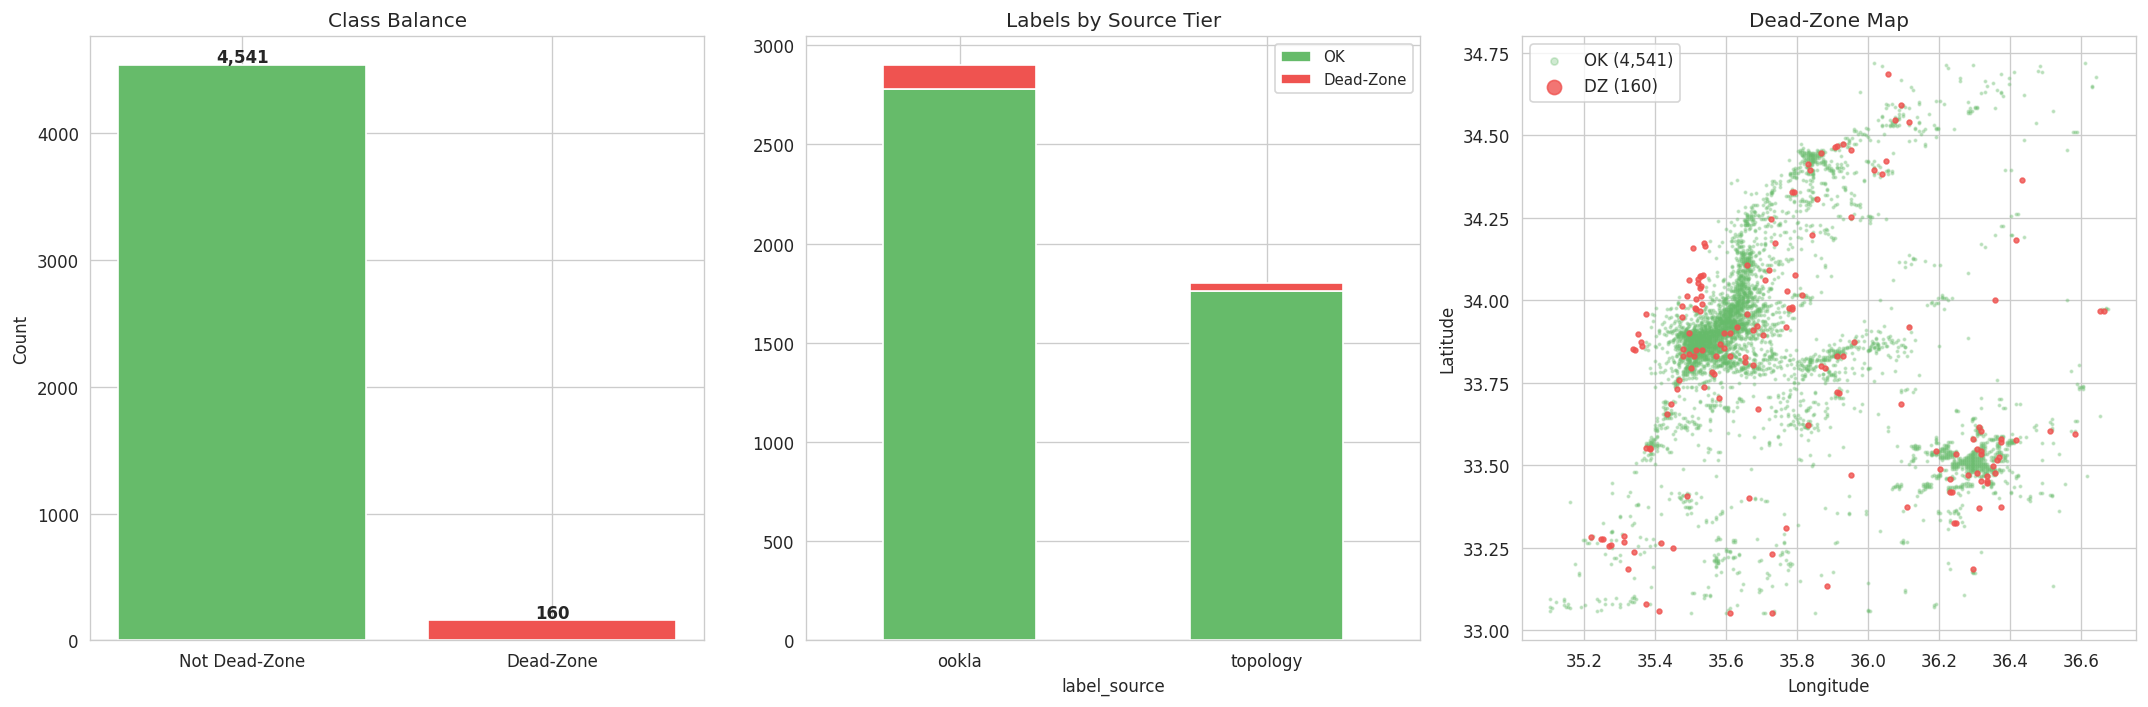

In [13]:
# ──────────────────────────────────────────────────────
# 3c. Visualize labeling results
# ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Class balance
ax = axes[0]
cts = dataset['is_deadzone'].value_counts().sort_index()
bars = ax.bar(['Not Dead-Zone', 'Dead-Zone'], cts.values, color=['#66BB6A', '#EF5350'])
for b, v in zip(bars, cts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+20, f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Class Balance'); ax.set_ylabel('Count')

# By source tier
ax = axes[1]
src_dz = dataset.groupby('label_source')['is_deadzone'].agg(['sum','count'])
src_dz['not_dz'] = src_dz['count'] - src_dz['sum']
src_dz[['not_dz','sum']].plot(kind='bar', stacked=True, ax=ax,
    color=['#66BB6A','#EF5350'], legend=False)
ax.set_title('Labels by Source Tier'); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['OK','Dead-Zone'], fontsize=9)

# Map
ax = axes[2]
ok = dataset[dataset['is_deadzone']==0]
dz = dataset[dataset['is_deadzone']==1]
ax.scatter(ok['longitude'], ok['latitude'], s=2, c='#66BB6A', alpha=0.3, label=f'OK ({len(ok):,})')
ax.scatter(dz['longitude'], dz['latitude'], s=8, c='#EF5350', alpha=0.8, label=f'DZ ({len(dz):,})')
ax.legend(markerscale=3)
ax.set_title('Dead-Zone Map'); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()


---
## 4. Feature engineering (43 features, 7 categories)

| Category | # | Examples |
|----------|---|----------|
| Spatial | 3 | latitude, longitude, distance_to_coast_km |
| Tower topology | 10 | nearest-distance, density in 1/3 km, mean neighbour signal |
| Propagation | 6 | COST-231 predicted RSRP, path loss, excess loss |
| Terrain | 5 | elevation, slope, relief, LoS obstruction score |
| Ookla performance | 6 | IDW-interpolated speed/latency aggregates |
| OSM urban | 4 | building / road / telecom density, urban class |
| App aggregates | 6 | H3 mean signal, std, dead-zone fraction |
| Categorical | 5 | operator, network_type, H3 r7/r9, urban class |

### 4a. Build the FeatureContext

The `FeatureContext` packages every context dataset into a single structure so
`build_feature_dataframe` can compute features consistently across all rows.


In [14]:
# ──────────────────────────────────────────────────────
# 4a. Build FeatureContext
# ──────────────────────────────────────────────────────
from deadzone_features import (
    FeatureContext, build_feature_dataframe,
    NUMERIC_FEATURES_V3, CATEGORICAL_FEATURES_V3
)

if not dem.empty and elev_col:
    dem_lats, dem_lons, dem_elevs = dem['latitude'].values, dem['longitude'].values, dem[elev_col].values
else:
    dem_lats = dem_lons = dem_elevs = None

ctx = FeatureContext(
    ref_cells=towers,
    ookla_df=ookla if not ookla.empty else None,
    dem_lats=dem_lats, dem_lons=dem_lons, dem_elevations=dem_elevs,
    osm_telecom_df=osm_telecom if not osm_telecom.empty else None,
    osm_buildings_df=osm_buildings if not osm_buildings.empty else None,
    osm_roads_df=osm_roads if not osm_roads.empty else None,
    coast_df=coastline if not coastline.empty else None,
)
print(f'Features: {len(NUMERIC_FEATURES_V3)} numeric + {len(CATEGORICAL_FEATURES_V3)} cat')


Features: 40 numeric + 5 cat


### 4b. Feature computation and per-source leakage masking

Every label tier has at least one feature column that is an algebraic
function of the label. Feeding those columns back to the classifier on
the rows they helped label produces a circular shortcut that evaluates
well in-sample and collapses on held-out spatial folds. We block this
by selectively blanking the label-generating columns per tier.

Two tiers need different masks:

- **Ookla-labeled rows.** The label is derived from `avg_d_kbps`. Mask
  every Ookla-aggregate column on those rows so the classifier has to
  predict slowness from terrain, topology, and clutter instead.
- **Topology-labeled rows.** The label is the fused output of five
  labeling functions. Two of those functions vote directly on feature
  columns (line-of-sight obstruction, building density, telecom
  density, same-operator density). The classifier trivially learns to
  reproduce those rules unless we also mask the voting columns on
  topology rows, so we do.

After masking, the `SimpleImputer` fills the blanks with the median
from the unmasked population, so those features remain available on
other tiers where they are not label-generating.


In [15]:
%%time
# ──────────────────────────────────────────────────────
# 4b. Compute features, then mask per-source label leakage
# ──────────────────────────────────────────────────────
feature_df = build_feature_dataframe(dataset, ctx)
# Preserve a pre-mask copy for the weak-supervision labeling functions,
# which need the raw feature values to cast honest votes.
feature_df_unmasked = feature_df.copy()
print(f'Feature matrix: {feature_df.shape[0]:,} x {feature_df.shape[1]}')

# Columns derived from, or voted on by, the Ookla-tier label.
ookla_leak_cols = [
    'ookla_avg_down_kbps', 'ookla_avg_up_kbps', 'ookla_avg_latency_ms',
    'ookla_tests', 'ookla_devices', 'ookla_distance_km',
]

# Columns that (a) the P.1812 label directly consumes, (b) the weak-
# supervision labeling functions vote on, or (c) are direct proxies for
# either. Masking them on topology rows prevents the classifier from
# memorising the label-generating rules as in-feature shortcuts.
topology_leak_cols = [
    # Direct P.1812 / COST-231 path-loss inputs
    'cost231_predicted_rsrp', 'cost231_path_loss_db',
    'free_space_path_loss_db', 'excess_path_loss_db',
    'serving_tower_distance_km',
    'same_group_nearest_distance_km',
    # Labeling-function voters
    'los_obstruction_score',              # lf_terrain_obstructed
    'osm_building_density_1km',           # lf_building_density
    'osm_telecom_density_1km',            # lf_building_density
    'osm_telecom_nearest_distance_km',    # proxy for lf_building_density
    'same_group_density_3km',             # lf_tower_distance
    'same_group_density_1km',             # proxy for lf_tower_distance
    'all_operator_density_1km',           # proxy for lf_tower_distance
    'ookla_distance_km',                  # drives lf_ookla_speed abstention
]

ookla_mask = dataset['label_source'] == 'ookla'
topo_mask = dataset['label_source'] == 'topology'

masked_ookla = 0
masked_topo = 0
for col in ookla_leak_cols:
    if col in feature_df.columns:
        feature_df.loc[ookla_mask, col] = np.nan
        masked_ookla += 1
for col in topology_leak_cols:
    if col in feature_df.columns:
        feature_df.loc[topo_mask, col] = np.nan
        masked_topo += 1

print(f'Leakage masking:')
print(f'  Ookla rows: masked {masked_ookla} columns on {ookla_mask.sum():,} rows')
print(f'  Topo rows : masked {masked_topo} columns on {topo_mask.sum():,} rows')
print(f'Remaining NaN share: {feature_df.isna().mean().mean():.1%}')



Feature matrix: 4,701 x 45
Leakage masking:
  Ookla rows: masked 6 columns on 2,901 rows
  Topo rows : masked 14 columns on 1,800 rows
Remaining NaN share: 29.0%
CPU times: user 15.6 s, sys: 0 ns, total: 15.6 s
Wall time: 15.6 s


### 4c. Weak-supervision relabeling

Topology-tier labels originally come from a single source (P.1812). Even with
a non-algebraic physics backend, a single-source label is fragile. We fuse
five independent noisy labeling functions with an accuracy-weighted log-odds
model; disagreement among the functions is reflected directly in the
per-row sample weight.


Labeling-function coverage (Lebanon)
                   lf  coverage  frac_dead  frac_live  n_votes
       lf_ookla_speed  0.693257   0.007671   0.992329     3259
 lf_p1812_propagation  0.336311   0.024035   0.975965     1581
    lf_tower_distance  0.477771   0.783170   0.216830     2246
lf_terrain_obstructed  0.699638   0.135604   0.864396     3289
  lf_building_density  0.010423   1.000000   0.000000       49

Hard-label agreement with original tiered labels: 89.7%
Mean soft label: 0.232
Mean confidence: 0.648

Replacing topology labels with weak-supervision fused labels
  Topology rows changed: 98 / 1,800
New topology-tier DZ rate: 7.6%


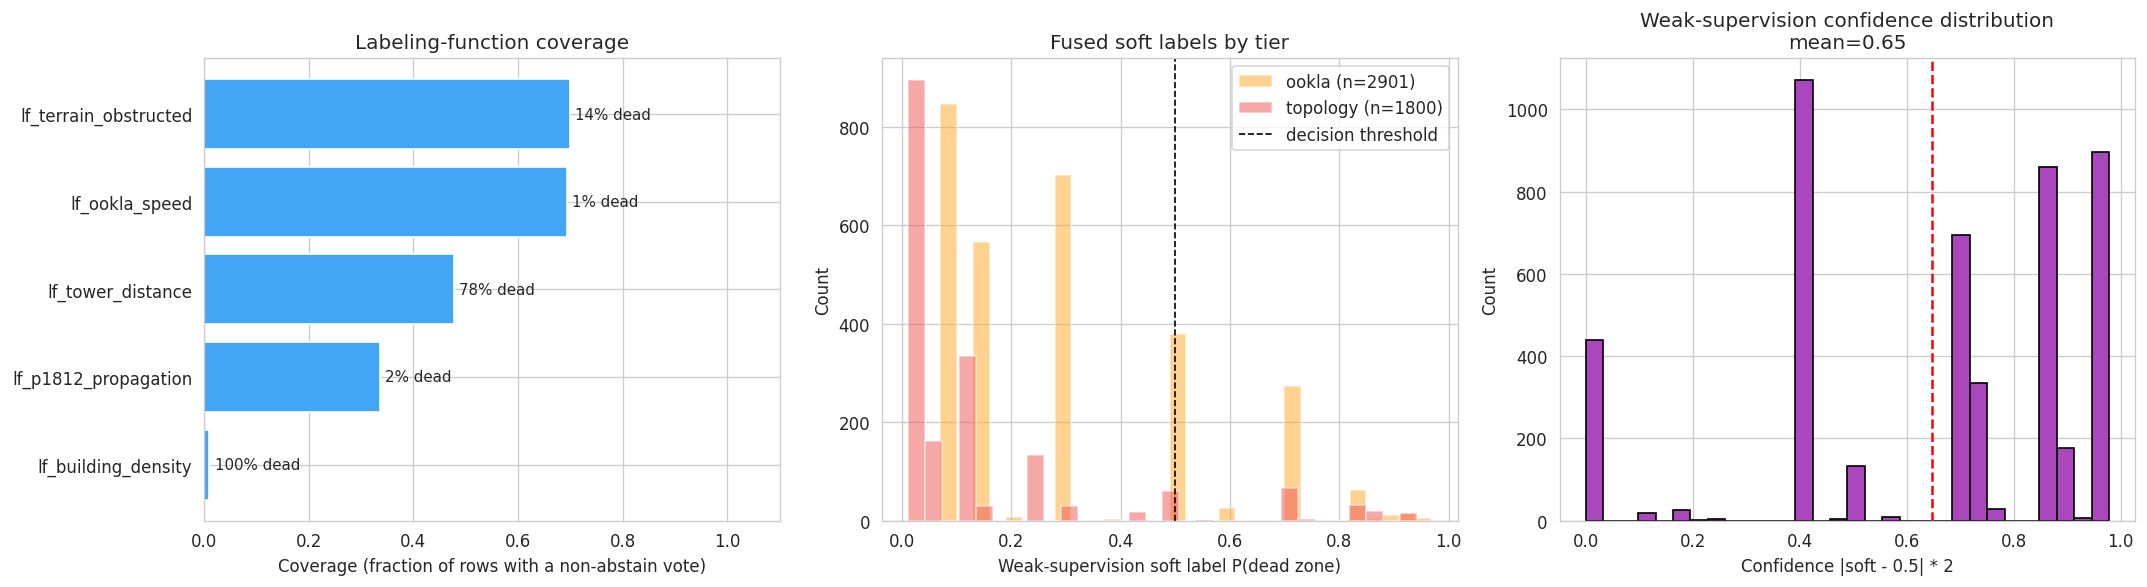

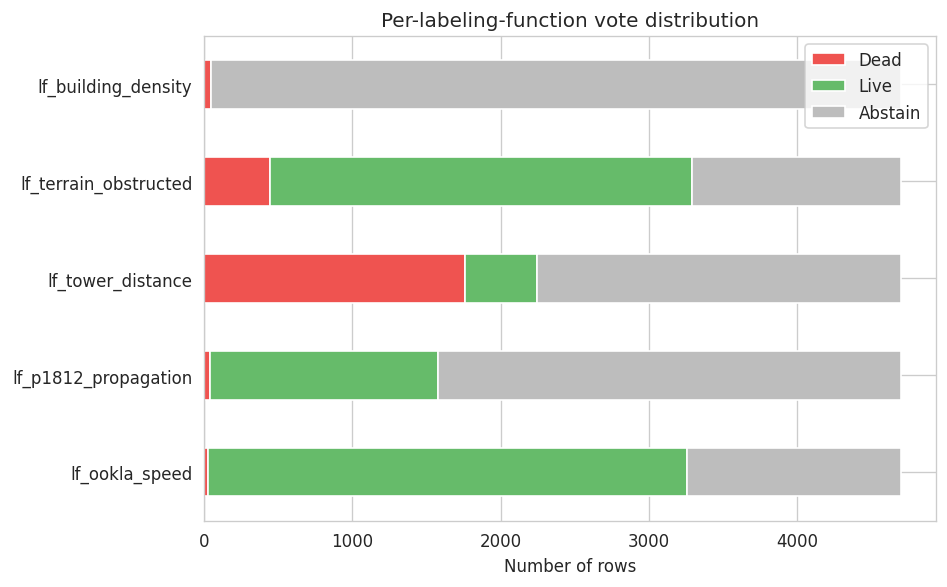

In [16]:
# ──────────────────────────────────────────────────────
# 4c. Weak-supervision relabeling for topology-tier rows
# ──────────────────────────────────────────────────────
# Relabel topology rows using five independent noisy labeling functions:
#
#   LF1: nearby Ookla speed-test < 1 Mbps    (throughput evidence)
#   LF2: P.1812 predicted RSRP < -110 dBm    (terrain/physics evidence)
#   LF3: > 5 km from tower with low density  (topology evidence)
#   LF4: high line-of-sight obstruction      (DEM evidence)
#   LF5: dense urban with no telecom         (clutter evidence)
#
# An accuracy-weighted log-odds generative model fuses the votes into a
# calibrated P(dead zone), removing single-feature dominance.
from deadzone_weak_supervision import (
    weak_supervision_labels, apply_lfs, report_lf_coverage,
)

# Build the labeling-function input frame: Ookla aggregates, topology,
# terrain, and OSM clutter come from the feature frame; merge in the
# P.1812 RSRP from the dataset for LF2.
lf_input = feature_df_unmasked.copy()
for col in ['p1812_rsrp_dbm']:
    if col in dataset.columns and col not in lf_input.columns:
        lf_input[col] = dataset[col].values

votes = apply_lfs(lf_input)
cov = report_lf_coverage(votes)
print('Labeling-function coverage (Lebanon)')
print('=' * 60)
print(cov.to_string(index=False))
print()

ws = weak_supervision_labels(lf_input)

orig = dataset['is_deadzone'].astype(int).values
hard = ws['ws_is_deadzone'].values
agree = (hard == orig).mean()
print(f'Hard-label agreement with original tiered labels: {agree:.1%}')
print(f'Mean soft label: {ws["ws_soft_label"].mean():.3f}')
print(f'Mean confidence: {ws["ws_confidence"].mean():.3f}')

# Replace only topology-tier labels with the fused weak-supervision output.
topo_m = dataset['label_source'] == 'topology'
n_changed = int((hard[topo_m.values] != orig[topo_m.values]).sum())
print(f'\nReplacing topology labels with weak-supervision fused labels')
print(f'  Topology rows changed: {n_changed:,} / {topo_m.sum():,}')

dataset.loc[topo_m, 'is_deadzone'] = hard[topo_m.values]
dataset.loc[topo_m, 'sample_weight'] = (
    dataset.loc[topo_m, 'sample_weight'].values *
    np.clip(ws.loc[topo_m, 'ws_confidence'].values, 0.2, 1.0)
)
print(f'New topology-tier DZ rate: '
      f'{dataset.loc[topo_m, "is_deadzone"].mean():.1%}')

# Refresh the labels frame for downstream training
labels = dataset[['is_deadzone','signal_target','sample_weight',
                   'regression_weight','label_source']].copy()

# Visualize labeling-function coverage, tier-wise soft labels, and confidence
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
cov_sorted = cov.sort_values('coverage', ascending=True)
ax.barh(cov_sorted['lf'], cov_sorted['coverage'], color='#42A5F5')
ax.set_xlabel('Coverage (fraction of rows with a non-abstain vote)')
ax.set_title('Labeling-function coverage')
for i, (lf, cv, fd) in enumerate(zip(cov_sorted['lf'], cov_sorted['coverage'], cov_sorted['frac_dead'])):
    ax.text(cv + 0.01, i, f'{fd:.0%} dead', va='center', fontsize=9)
ax.set_xlim(0, 1.1)

ax = axes[1]
for tier, color in [('app','#66BB6A'),('ookla','#FFA726'),('topology','#EF5350')]:
    m = dataset['label_source'] == tier
    if m.any():
        ax.hist(ws.loc[m,'ws_soft_label'], bins=30, alpha=0.5,
                 label=f'{tier} (n={m.sum()})', color=color)
ax.axvline(0.5, color='k', ls='--', lw=1, label='decision threshold')
ax.set_xlabel('Weak-supervision soft label P(dead zone)')
ax.set_ylabel('Count')
ax.set_title('Fused soft labels by tier')
ax.legend()

ax = axes[2]
ax.hist(ws['ws_confidence'], bins=30, color='#AB47BC', edgecolor='black')
ax.set_xlabel('Confidence |soft - 0.5| * 2')
ax.set_ylabel('Count')
ax.set_title(f'Weak-supervision confidence distribution\nmean={ws["ws_confidence"].mean():.2f}')
ax.axvline(ws['ws_confidence'].mean(), color='red', ls='--')
plt.tight_layout(); plt.show()

# Per-labeling-function vote distribution
fig, ax = plt.subplots(figsize=(8, 5))
vote_counts = pd.DataFrame({
    'Dead':    (votes == 1).sum(),
    'Live':    (votes == 0).sum(),
    'Abstain': (votes == -1).sum(),
})
vote_counts.plot(kind='barh', stacked=True, ax=ax,
                  color=['#EF5350','#66BB6A','#BDBDBD'])
ax.set_xlabel('Number of rows')
ax.set_title('Per-labeling-function vote distribution')
plt.tight_layout(); plt.show()


### 4d. Feature correlation with the dead-zone label

Per-feature Pearson correlation between each numeric feature and the fused
binary dead-zone label. Very high magnitudes (greater than about 0.9) are a
warning sign for a direct algebraic link between feature and label and should
be investigated before training.


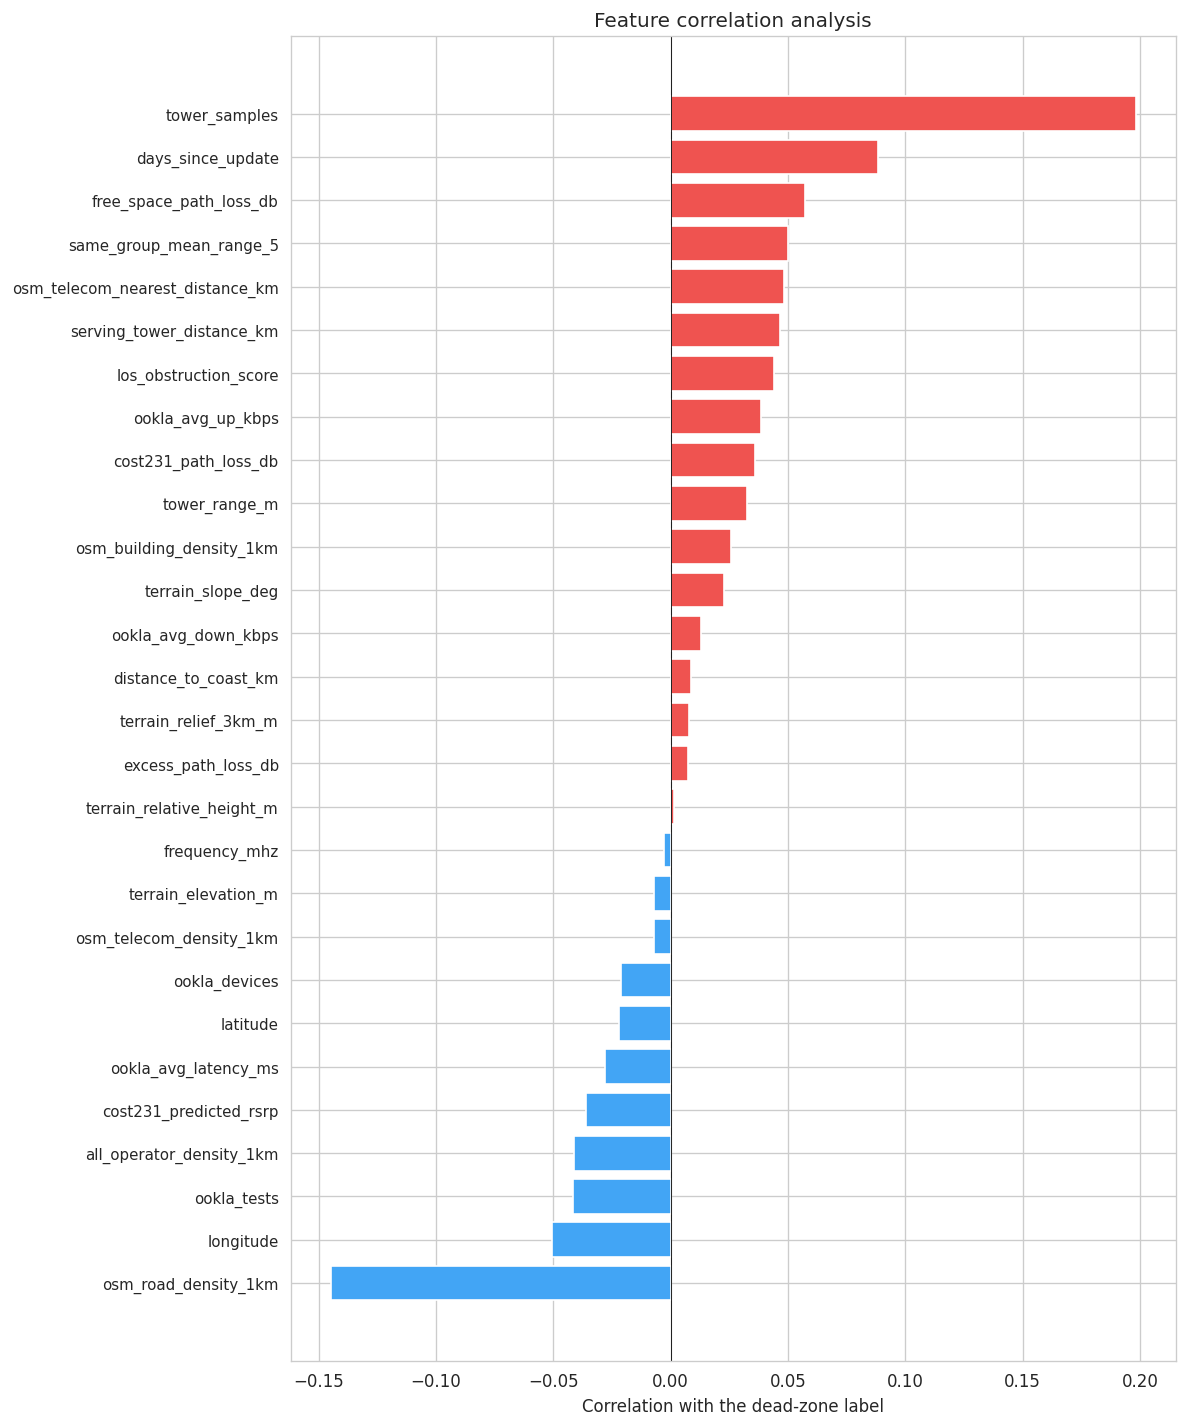

In [17]:
# ─────────────────────────────────────────────────────
# 4d. Feature correlation with the dead-zone label
# ─────────────────────────────────────────────────────
# Drop constant or all-NaN columns before computing Pearson correlation
# (avoids divide-by-zero warnings and keeps the plot informative).
_num = feature_df[NUMERIC_FEATURES_V3]
_std = _num.std(skipna=True)
_keep = [c for c in NUMERIC_FEATURES_V3 if _std.get(c, 0) > 0 and _num[c].notna().sum() > 1]
corr = _num[_keep].corrwith(
    dataset['is_deadzone'].astype(float)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#EF5350' if v > 0 else '#42A5F5' for v in corr.values]
ax.barh(range(len(corr)), corr.values, color=colors)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index, fontsize=9)
ax.set_xlabel('Correlation with the dead-zone label')
ax.set_title('Feature correlation analysis')
ax.axvline(x=0, color='black', lw=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


---
## 5. Model training

Two LightGBM models are trained with spatially grouped cross-validation:

1. **Regressor** — Huber loss, predicts continuous RSRP in dBm.
2. **Classifier** — binary, predicts P(dead zone) from the primitive feature
   set (topology, propagation aggregates, terrain, clutter, and the tier
   masking described in section 4b).

Both models use sample weights that reflect label confidence (app > Ookla >
topology) scaled by the per-row weak-supervision confidence.

---


In [18]:
# ──────────────────────────────────────────────────────
# 5a. Prepare labels
# ──────────────────────────────────────────────────────
from deadzone_training import train_dual_model

TUNE = False  # Set True for Optuna hyperparameter search

labels = dataset[['is_deadzone','signal_target','sample_weight',
                   'regression_weight','label_source']].copy()

print(f'Training: {len(labels):,} samples, DZ rate: {labels["is_deadzone"].mean():.1%}')
for src in labels['label_source'].unique():
    m = labels['label_source'] == src
    print(f'  {src}: n={m.sum():,}, weight={labels.loc[m,"sample_weight"].mean():.1f}')


Training: 4,701 samples, DZ rate: 5.5%
  ookla: n=2,901, weight=2.0
  topology: n=1,800, weight=0.4


### 5b. Fit regressor + classifier with spatial CV

`train_dual_model` uses H3-resolution-5 cell membership as the `GroupKFold` key,
so geographically adjacent points never straddle train/validation folds
(prevents spatial leakage that would otherwise inflate AUC).


In [19]:
%%time
# ──────────────────────────────────────────────────────
# 5b. Train dual LightGBM
# ──────────────────────────────────────────────────────
result = train_dual_model(feature_df=feature_df, labels=labels, tune=TUNE)

regressor = result['regressor']
classifier = result['classifier']
metrics = result['metrics']
reg_params = result['reg_params']
cls_params = result['cls_params']
print('Training complete.')


Generating out-of-fold regressor predictions...
Training final regressor...
Training final classifier on primitive features...
Evaluating...
Training complete.
CPU times: user 1min 46s, sys: 297 ms, total: 1min 47s
Wall time: 9.85 s


---
## 6. Evaluation (four independent lenses)

| Section | Metric | What it tells us |
|---|--------|-----------------|
| 6a | Train-set and spatial-CV metrics | Internal model fit and held-out Lebanon AUC |
| 6b | Prediction distribution plots | Regressor calibration and classifier probability spread |
| 6c | Berlin V2X transfer RMSE and AUC | External validation against real RSRP (no Lebanon labels needed) |
| 6d | Ookla-agreement metric (Lebanon) | Honest Lebanon validation: predictions vs real slow tiles |

The two headline metrics are the Berlin transfer RMSE (tested against real
ground truth) and the Lebanon Ookla-agreement AUC (validates deployment-
relevant predictions).


Train-set metrics (reference only; expect inflation)

Signal regressor
  rmse           : 11.493
  mae            : 8.208
  r2             : 0.618
  median_ae      : 5.568

Dead-zone classifier
  accuracy       : 0.9864
  roc_auc        : 0.9984
  pr_auc         : 0.9650
  precision      : 0.8031
  recall         : 0.9961
  f1             : 0.8893
Spatial cross-validation at H3 resolution 5 (approx 8 km hexes)

H3 res 5: groups=85, folds=5
  fold 0: n_test=1,083, ROC-AUC=0.4737089434111595
  fold 1: n_test=905, ROC-AUC=0.589634199702459
  fold 2: n_test=905, ROC-AUC=0.5507500095664486
  fold 3: n_test=904, ROC-AUC=0.7280285035629452
  fold 4: n_test=904, ROC-AUC=0.7550079272075549

Stress test: spatial cross-validation at H3 resolution 4 (approx 25 km)

H3 res 4: groups=18, folds=5
  fold 0: n_test=1,370, ROC-AUC=0.8304304181577152
  fold 1: n_test=1,129, ROC-AUC=0.7695433598659405
  fold 2: n_test=735, ROC-AUC=0.5354673342870768
  fold 3: n_test=734, ROC-AUC=0.6566386554621849
  fold 

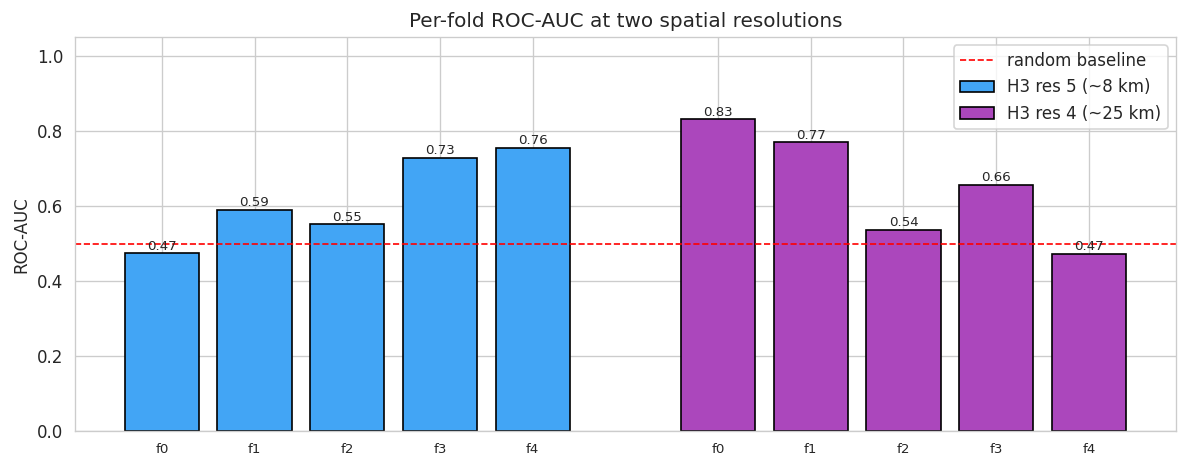


Tuned dead-class threshold (OOF F1-max): 0.410
  F1           : 0.325
  Precision    : 0.405
  Recall       : 0.271

Classification report at the tuned threshold
              precision    recall  f1-score   support

        Live      0.958     0.977     0.968      4443
        Dead      0.405     0.271     0.325       258

    accuracy                          0.938      4701
   macro avg      0.682     0.624     0.646      4701
weighted avg      0.928     0.938     0.932      4701



In [20]:
# ──────────────────────────────────────────────────────
# 6a. Metrics (train-set reference + spatial cross-validation)
# ──────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_recall_fscore_support, classification_report
)
from sklearn.pipeline import Pipeline
from deadzone_training import (
    assign_spatial_fold_groups, spatial_cross_validate,
    build_preprocessor, default_classifier_params
)
import lightgbm as lgb
import h3

# Train-set metrics — reference only; expect inflated numbers.
print('=' * 60)
print('Train-set metrics (reference only; expect inflation)')
print('=' * 60)
if 'regressor' in metrics:
    print('\nSignal regressor')
    for k in ['rmse','mae','r2','median_ae']:
        if k in metrics['regressor']: print(f'  {k:15s}: {metrics["regressor"][k]:.3f}')
if 'classifier' in metrics:
    print('\nDead-zone classifier')
    for k in ['accuracy','roc_auc','pr_auc','precision','recall','f1']:
        if k in metrics['classifier']: print(f'  {k:15s}: {metrics["classifier"][k]:.4f}')

from sklearn.model_selection import GroupKFold

def run_spatial_cv(fold_groups, name, store_oof=False):
    n_groups = len(np.unique(fold_groups))
    n_folds = min(5, n_groups)
    print(f'\n{name}: groups={n_groups}, folds={n_folds}')
    gkf = GroupKFold(n_splits=n_folds)
    oof = np.full(len(feature_df), np.nan)
    is_test = np.zeros(len(feature_df), dtype=bool)
    fold_aucs = []
    for fi, (tr, te) in enumerate(gkf.split(feature_df, labels['is_deadzone'], fold_groups)):
        y_tr = labels.iloc[tr]['is_deadzone'].astype(int).values
        y_te = labels.iloc[te]['is_deadzone'].astype(int).values
        w_tr = labels.iloc[tr]['sample_weight'].values
        pos = max(y_tr.mean(), 1e-3)
        pipe = Pipeline([
            ('pre', build_preprocessor()),
            ('cls', lgb.LGBMClassifier(**default_classifier_params(pos))),
        ])
        pipe.fit(feature_df.iloc[tr], y_tr, cls__sample_weight=w_tr)
        p = pipe.predict_proba(feature_df.iloc[te])[:, 1]
        oof[te] = p
        is_test[te] = True
        try:
            a = roc_auc_score(y_te, p) if len(np.unique(y_te)) > 1 else float('nan')
        except Exception:
            a = float('nan')
        fold_aucs.append(a)
        print(f'  fold {fi}: n_test={len(te):,}, ROC-AUC={a}')
    if store_oof:
        return oof, is_test, fold_aucs
    return None, None, fold_aucs

# Primary: H3 res 5 (~8 km hexes) — keeps the feature-computation
# convention consistent and gives five geographically distinct folds.
print('=' * 60)
print('Spatial cross-validation at H3 resolution 5 (approx 8 km hexes)')
print('=' * 60)
groups_r5 = assign_spatial_fold_groups(
    feature_df['latitude'].values, feature_df['longitude'].values
)
oof_proba, oof_is_test, fold_aucs_r5 = run_spatial_cv(groups_r5, 'H3 res 5', store_oof=True)

# Stress test: H3 res 4 (~25 km hexes). If AUC drops materially
# between res 5 and res 4 the earlier number was partly spatial
# memorisation; if it stays, the model is generalising.
print('\n' + '=' * 60)
print('Stress test: spatial cross-validation at H3 resolution 4 (approx 25 km)')
print('=' * 60)
groups_r4 = np.array([
    h3.latlng_to_cell(float(a), float(o), 4)
    for a, o in zip(feature_df['latitude'].values, feature_df['longitude'].values)
])
_, _, fold_aucs_r4 = run_spatial_cv(groups_r4, 'H3 res 4', store_oof=False)

# Aggregate metrics on the H3-res-5 OOF probabilities (our headline).
valid = oof_is_test
y_true_all = labels['is_deadzone'].astype(int).values[valid]
y_prob_all = oof_proba[valid]
y_src_all  = labels['label_source'].values[valid]
y_pred_all = (y_prob_all > 0.5).astype(int)

print('\nOverall spatial-CV metrics at H3 res 5 (OOF concatenated)')
print(f'  n            : {len(y_true_all):,}')
print(f'  Accuracy     : {accuracy_score(y_true_all, y_pred_all):.4f}')
if len(np.unique(y_true_all)) > 1:
    print(f'  ROC-AUC      : {roc_auc_score(y_true_all, y_prob_all):.4f}')
    print(f'  PR-AUC       : {average_precision_score(y_true_all, y_prob_all):.4f}')

# Per-tier breakdown
print('\nPer-tier spatial-CV ROC-AUC (H3 res 5)')
for src in ['app','ookla','topology']:
    m = y_src_all == src
    if m.sum() > 10 and len(np.unique(y_true_all[m])) > 1:
        try:
            a = roc_auc_score(y_true_all[m], y_prob_all[m])
            print(f'  {src:10s} (n={m.sum():,}): {a:.4f}')
        except Exception as e:
            print(f'  {src}: error {e}')

print('\n' + classification_report(y_true_all, y_pred_all,
                                     target_names=['Live','Dead'], digits=3))

# Per-fold visualisation: shows geographic variance at both scales.
fig, ax = plt.subplots(figsize=(10, 4))
x5 = np.arange(len(fold_aucs_r5))
x4 = np.arange(len(fold_aucs_r4)) + len(fold_aucs_r5) + 1
ax.bar(x5, fold_aucs_r5, color='#42A5F5', edgecolor='black', label='H3 res 5 (~8 km)')
ax.bar(x4, fold_aucs_r4, color='#AB47BC', edgecolor='black', label='H3 res 4 (~25 km)')
for xi, v in zip(list(x5) + list(x4), list(fold_aucs_r5) + list(fold_aucs_r4)):
    if np.isfinite(v):
        ax.text(xi, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='red', ls='--', lw=1, label='random baseline')
ax.set_xticks(list(x5) + list(x4))
ax.set_xticklabels([f'f{i}' for i in range(len(fold_aucs_r5))]
                    + [f'f{i}' for i in range(len(fold_aucs_r4))], fontsize=8)
ax.set_ylabel('ROC-AUC')
ax.set_title('Per-fold ROC-AUC at two spatial resolutions')
ax.legend()
plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────
# 6a-bis. Threshold tuning on OOF probabilities
# ─────────────────────────────────────────────────────
# The default 0.5 threshold optimises accuracy on an imbalanced label and
# produces low dead-class recall. Pick the threshold that maximises F1 on
# the dead class over the OOF predictions, and report both side-by-side.
from sklearn.metrics import f1_score, precision_score, recall_score

grid = np.linspace(0.05, 0.95, 91)
f1s = np.array([f1_score(y_true_all, (y_prob_all > t).astype(int), zero_division=0) for t in grid])
best_idx = int(np.argmax(f1s))
tuned_threshold = float(grid[best_idx])
y_pred_t = (y_prob_all > tuned_threshold).astype(int)

print(f'\nTuned dead-class threshold (OOF F1-max): {tuned_threshold:.3f}')
print(f'  F1           : {f1s[best_idx]:.3f}')
print(f'  Precision    : {precision_score(y_true_all, y_pred_t, zero_division=0):.3f}')
print(f'  Recall       : {recall_score(y_true_all, y_pred_t, zero_division=0):.3f}')
print('\nClassification report at the tuned threshold')
print(classification_report(y_true_all, y_pred_t,
                             target_names=['Live','Dead'], digits=3))


### 6b. Prediction distribution diagnostics

- Actual vs predicted RSRP on OOF samples (regressor calibration)
- Classifier probability distribution by true class (separability)
- ROC curve


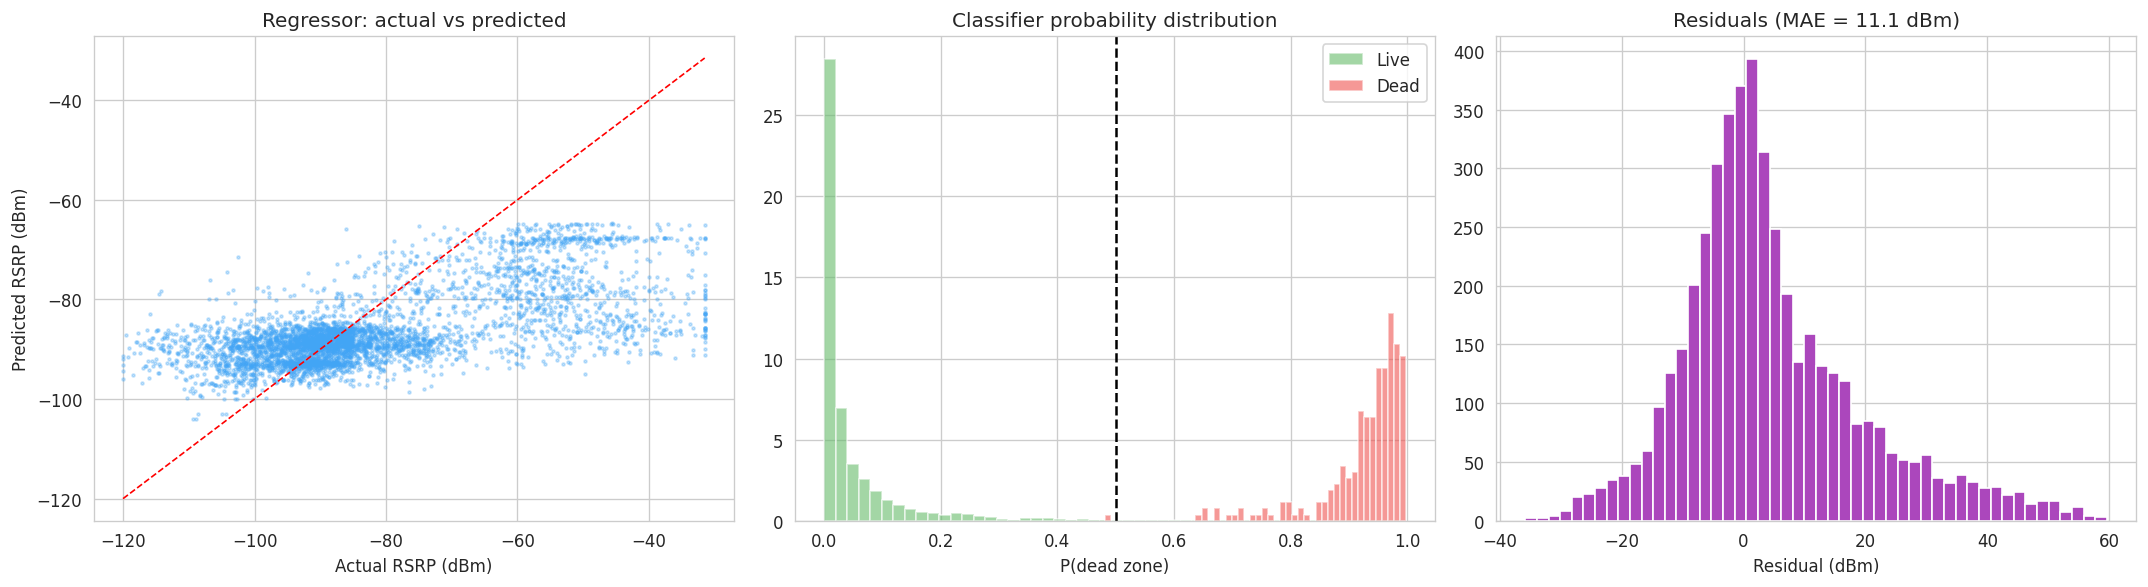

In [21]:
# ──────────────────────────────────────────────────────
# 6b. Prediction distribution plots
# ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs predicted RSRP from the regressor's out-of-fold predictions
oof_preds = result['oof_predictions']
ax = axes[0]
vr = ~np.isnan(labels['signal_target'].values)
if vr.any():
    ax.scatter(labels['signal_target'].values[vr], oof_preds[vr],
              s=3, alpha=0.3, c='#42A5F5')
    lims = [labels['signal_target'].dropna().min(), labels['signal_target'].dropna().max()]
    ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('Actual RSRP (dBm)')
ax.set_ylabel('Predicted RSRP (dBm)')
ax.set_title('Regressor: actual vs predicted')

# The classifier consumes the primitive feature set directly.
cls_feature_df = feature_df

# Classifier probability distribution split by true class
ax = axes[1]
proba = classifier.predict_proba(cls_feature_df)[:, 1]
y = labels['is_deadzone'].values
ax.hist(proba[y==0], bins=50, alpha=0.6, color='#66BB6A', label='Live', density=True)
ax.hist(proba[y==1], bins=50, alpha=0.6, color='#EF5350', label='Dead', density=True)
ax.axvline(x=0.5, color='black', ls='--')
ax.set_title('Classifier probability distribution')
ax.set_xlabel('P(dead zone)')
ax.legend()

# Regressor residuals
ax = axes[2]
if vr.any():
    res = labels['signal_target'].values[vr] - oof_preds[vr]
    ax.hist(res, bins=50, color='#AB47BC', edgecolor='white')
    ax.set_title(f'Residuals (MAE = {np.abs(res).mean():.1f} dBm)')
    ax.set_xlabel('Residual (dBm)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'reports' / 'eval_plots.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6c. External geographic transfer

Two external tests are attempted. Both place the Lebanon-trained model on
data it has never seen, so both break the spatial-structure assumption
that lets training and validation share macroscopic geographic patterns.

1. **Berlin V2X (optional, manual data).** Real RSRP drive-test measurements
   from Fraunhofer HHI. This is the canonical real-RSRP transfer test. The
   parquet is distributed from IEEE DataPort behind a login, so the notebook
   only runs this step when `cellular_dataframe.parquet` is already present
   at `DATA_DIR/berlin_v2x/` (placed there either via Google Drive or by
   setting the environment variable `BERLIN_V2X_URL`).
2. **Ookla cross-city (always runs).** The Ookla Open Data parquet already
   covers the whole world. We load a non-Lebanon bounding box (Berlin) and
   evaluate whether the Lebanon-trained classifier agrees with Ookla-slow
   tiles there. This does not test real RSRP directly — it tests whether
   the learned features transfer geographically, using the same throughput
   proxy as the Lebanon agreement metric.


Loaded Berlin V2X: 194,916 rows
Berlin V2X: 194,916 real RSRP measurements
Computing features for Berlin sample ...
  Features: 3000/3000

Berlin V2X transfer metrics
  n_samples           : 2999
  rsrp_rmse           : 12.1865
  rsrp_mae            : 9.7410
  rsrp_r2             : -0.0235
  cls_accuracy        : 0.9570
  cls_roc_auc         : 0.5538
  cls_pr_auc          : 0.0480
  dead_rate           : 0.0430
  RMSE interpretation: 12.2 dB — reasonable transfer


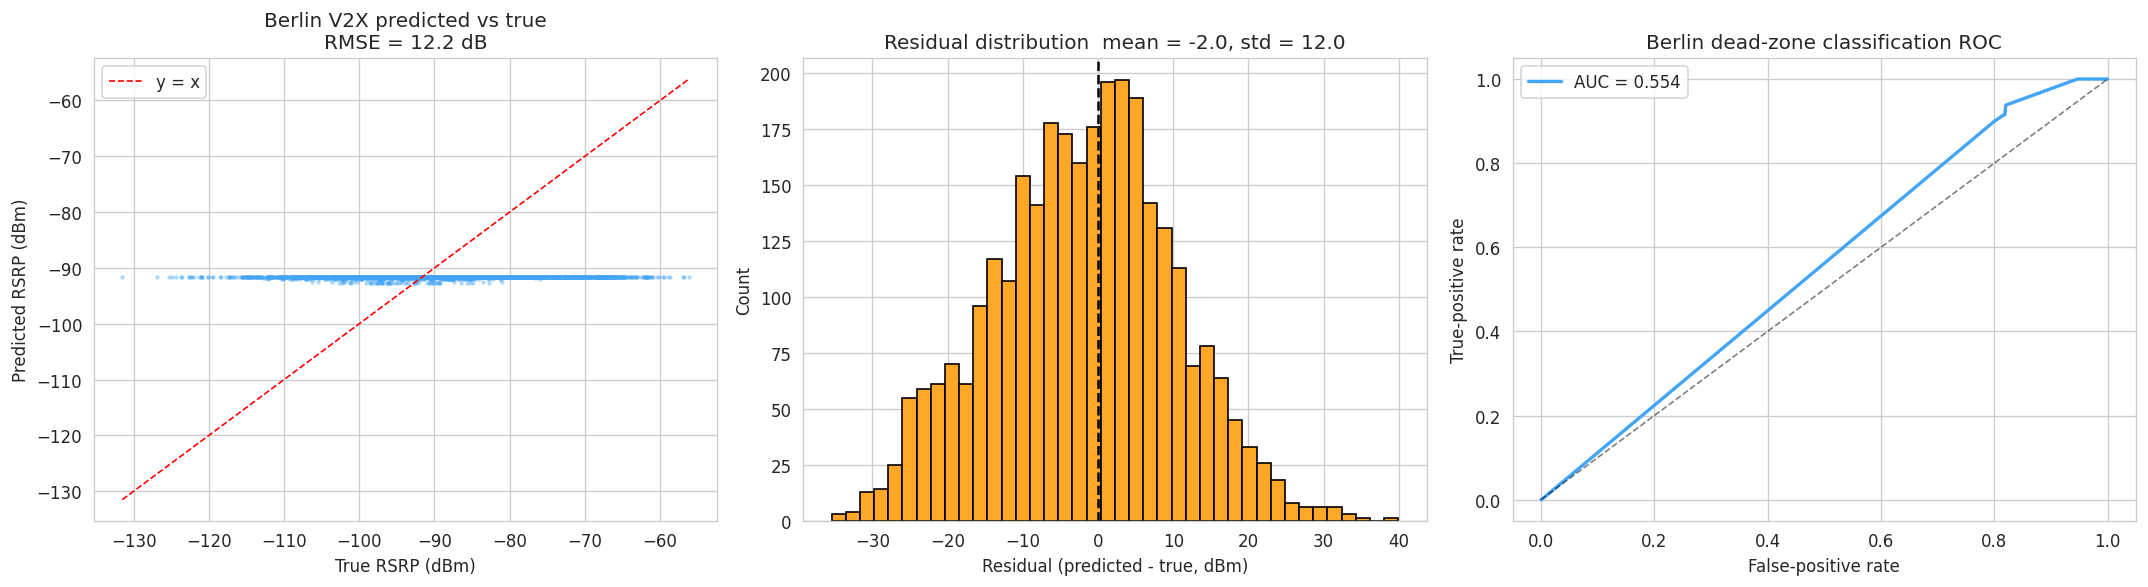

In [22]:
# ──────────────────────────────────────────────────────
# 6c. Berlin V2X transfer evaluation (runs only when data is present)
# ──────────────────────────────────────────────────────
from pathlib import Path as _P
from deadzone_transfer import (
    download_berlin_v2x, get_berlin_opencellid,
    compute_transfer_features, evaluate_transfer,
)

berlin_cache = DATA_DIR / 'berlin_v2x'
berlin_parquet = berlin_cache / 'cellular_dataframe.parquet'

# The canonical Berlin V2X parquet is distributed from IEEE DataPort
# behind a login wall; it is not mirrored on HuggingFace. Run this
# cell only if the file is already on disk (e.g. uploaded via Drive).
# Callers can also point BERLIN_V2X_URL at a private HTTP mirror.
transfer_metrics = None
if not berlin_parquet.exists() and os.environ.get('BERLIN_V2X_URL'):
    try:
        import urllib.request as _ur
        berlin_cache.mkdir(parents=True, exist_ok=True)
        print(f"Downloading Berlin V2X from $BERLIN_V2X_URL ...")
        _ur.urlretrieve(os.environ['BERLIN_V2X_URL'], berlin_parquet)
    except Exception as e:
        print(f'Env-var URL fetch failed: {e}')

if berlin_parquet.exists():
    try:
        berlin = download_berlin_v2x(cache_dir=str(berlin_cache))
        print(f'Berlin V2X: {len(berlin):,} real RSRP measurements')
        berlin_towers = get_berlin_opencellid(cache_dir=str(DATA_DIR))

        n_test = min(len(berlin), 3000)
        berlin_sample = berlin.sample(n_test, random_state=42).reset_index(drop=True)

        print('Computing features for Berlin sample ...')
        berlin_feats = compute_transfer_features(
            berlin_sample, berlin_towers, max_rows=n_test,
        )
        needed = list(feature_df.columns)
        for c in needed:
            if c not in berlin_feats.columns:
                berlin_feats[c] = np.nan
        berlin_feats = berlin_feats[needed]

        mask = berlin_sample['rsrp'].notna() & (berlin_sample['rsrp'] > -140)
        berlin_feats = berlin_feats[mask.values]
        true_rsrp = berlin_sample.loc[mask, 'rsrp'].values

        transfer_metrics = evaluate_transfer(
            regressor=regressor, classifier=classifier,
            features_df=berlin_feats, true_rsrp=true_rsrp,
            dead_threshold_dbm=-110.0,
        )
        print('\nBerlin V2X transfer metrics')
        for k, v in transfer_metrics.items():
            if isinstance(v, float):
                print(f'  {k:20s}: {v:.4f}')
            else:
                print(f'  {k:20s}: {v}')
        if 'rsrp_rmse' in transfer_metrics:
            rmse = transfer_metrics['rsrp_rmse']
            note = ('strong transfer' if rmse < 12 else
                    'reasonable transfer' if rmse < 18 else
                    'weak transfer')
            print(f'  RMSE interpretation: {rmse:.1f} dB — {note}')
    except Exception as e:
        print(f'Berlin V2X transfer eval failed: {e}')
else:
    print('Berlin V2X parquet not found at', berlin_parquet)
    print('This cell is skipped. To enable it, place')
    print('cellular_dataframe.parquet at that path (e.g. via Drive upload)')
    print('or set BERLIN_V2X_URL to a private HTTP mirror.')

# Visualisation when metrics are available
if transfer_metrics is not None and 'rsrp_rmse' in transfer_metrics:
    try:
        pred_rsrp_berlin = regressor.predict(berlin_feats)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        ax = axes[0]
        ax.scatter(true_rsrp, pred_rsrp_berlin, s=3, alpha=0.3, c='#42A5F5')
        lims = [min(true_rsrp.min(), pred_rsrp_berlin.min()),
                 max(true_rsrp.max(), pred_rsrp_berlin.max())]
        ax.plot(lims, lims, 'r--', lw=1, label='y = x')
        ax.set_xlabel('True RSRP (dBm)')
        ax.set_ylabel('Predicted RSRP (dBm)')
        ax.set_title(f'Berlin V2X predicted vs true\nRMSE = {transfer_metrics["rsrp_rmse"]:.1f} dB')
        ax.legend()
        ax = axes[1]
        resid = pred_rsrp_berlin - true_rsrp
        ax.hist(resid, bins=40, color='#FFA726', edgecolor='black')
        ax.axvline(0, color='k', ls='--')
        ax.set_xlabel('Residual (predicted - true, dBm)')
        ax.set_ylabel('Count')
        ax.set_title(f'Residual distribution  mean = {resid.mean():.1f}, std = {resid.std():.1f}')
        ax = axes[2]
        from sklearn.metrics import roc_curve
        y_true_b = (true_rsrp < -110).astype(int)
        if len(np.unique(y_true_b)) > 1:
            proba_b = classifier.predict_proba(berlin_feats)[:, 1]
            fpr, tpr, _ = roc_curve(y_true_b, proba_b)
            ax.plot(fpr, tpr, lw=2, c='#42A5F5',
                    label=f'AUC = {transfer_metrics.get("cls_roc_auc", 0):.3f}')
            ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
            ax.set_xlabel('False-positive rate')
            ax.set_ylabel('True-positive rate')
            ax.set_title('Berlin dead-zone classification ROC')
            ax.legend()
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f'Berlin transfer visualisation failed: {e}')


---
## 6c2. Ookla cross-city (always runs)

Load the Berlin slice of the global Ookla Open Data parquet, run the Lebanon
feature pipeline on it, and evaluate how often the Lebanon-trained classifier
agrees with Berlin's Ookla-slow tiles. This is a public-data substitute for
Berlin V2X that always works, with the caveat that it only tests
transfer of the Ookla-slowness proxy, not real RSRP.

## 6d. Lebanon Ookla-agreement (spatial-CV out-of-fold)

Validates the Lebanon predictions against real Ookla-slow tiles using the
out-of-fold probabilities from section 6a, so no prediction was trained on
its own row.


Berlin Ookla tiles: 3,821
  Features: 2000/2000

Berlin Ookla cross-city metrics
  n_samples             : 2000
  ookla_slow_rate       : 0.0090
  agreement_roc_auc     : 0.4854
  agreement_pr_auc      : 0.0084
  binary_agreement      : 0.9910
  true_positive_rate    : 0.0000
  false_positive_rate   : 0.0000

Lebanon Ookla-agreement metrics (spatial-CV out-of-fold)
  n_samples             : 2901
  ookla_slow_rate       : 0.0276
  agreement_roc_auc     : 0.4862
  agreement_pr_auc      : 0.0271
  binary_agreement      : 0.9628
  true_positive_rate    : 0.0125
  false_positive_rate   : 0.0103


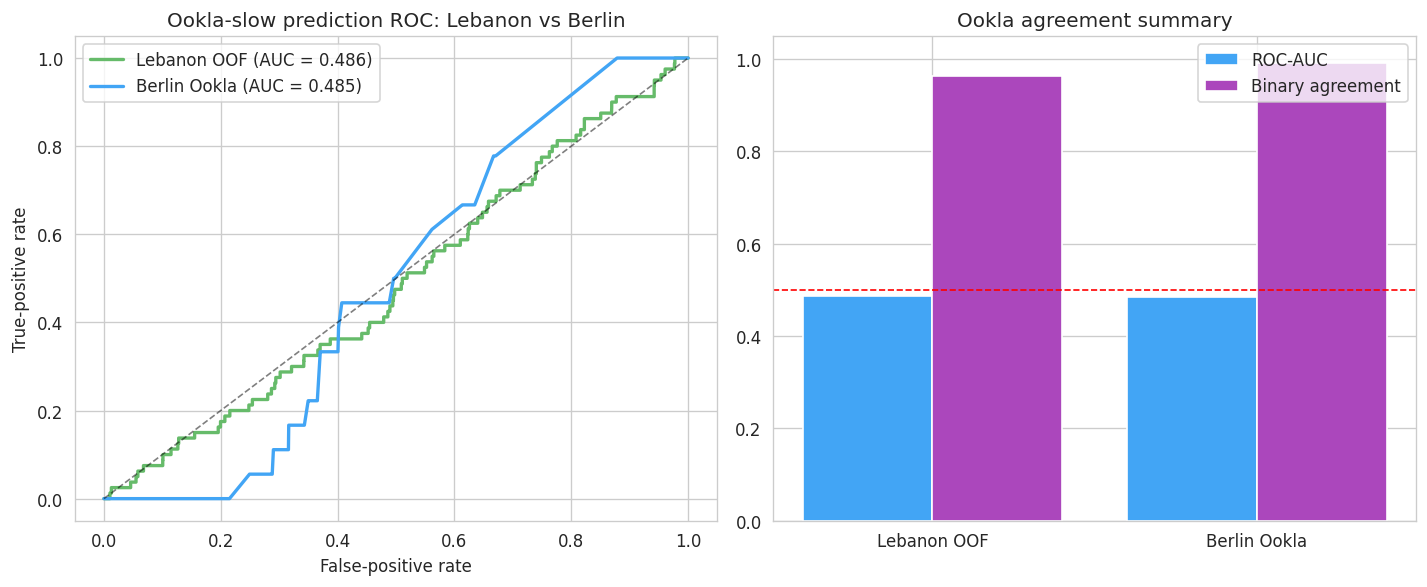

In [23]:
# ──────────────────────────────────────────────────────
# 6c2. Ookla cross-city transfer (Berlin Ookla tiles)
# ──────────────────────────────────────────────────────
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, confusion_matrix,
)

BERLIN_BBOX = (52.3, 13.1, 52.7, 13.8)  # (lat_min, lon_min, lat_max, lon_max)
cross_metrics = None
try:
    from deadzone_model import load_ookla_tiles
    from deadzone_features import build_feature_dataframe as _bfd
    from deadzone_features import FeatureContext as _FC

    berlin_ookla = load_ookla_tiles(
        DATA_DIR / 'ookla_mobile_q4_2025.parquet', bbox=BERLIN_BBOX,
    )
    print(f'Berlin Ookla tiles: {len(berlin_ookla):,}')
    if len(berlin_ookla) < 50:
        raise RuntimeError('too few Berlin tiles')

    # Minimal FeatureContext: towers (synthetic fallback is fine)
    berlin_towers = get_berlin_opencellid(cache_dir=str(DATA_DIR))
    xcity_ctx = _FC(
        ref_cells=berlin_towers,
        ookla_df=None,
        dem_lats=None, dem_lons=None, dem_elevations=None,
        osm_telecom_df=None, osm_buildings_df=None, osm_roads_df=None,
        coast_df=None, h3_aggregates={},
    )
    # Construct a dataset-shaped frame for build_feature_dataframe.
    n_x = min(len(berlin_ookla), 2000)
    bs = berlin_ookla.sample(n_x, random_state=0).reset_index(drop=True)
    bs_ds = pd.DataFrame({
        'latitude': bs['latitude'],
        'longitude': bs['longitude'],
        'operator': 'Unknown',
        'network_type': '4G',
        'frequency_band': 'LTE_1800',
        'is_deadzone': 0,
    })
    bx_feats = _bfd(bs_ds, xcity_ctx)
    # Align columns with the Lebanon feature matrix
    for c in feature_df.columns:
        if c not in bx_feats.columns:
            bx_feats[c] = np.nan
    bx_feats = bx_feats[feature_df.columns]

    bx_proba = classifier.predict_proba(bx_feats)[:, 1]
    y_true_x = (bs['avg_d_kbps'].values < 1000).astype(int)
    y_pred_x = (bx_proba > 0.5).astype(int)

    n_x = len(y_true_x)
    slow_rate_x = float(y_true_x.mean())
    bin_x = float((y_pred_x == y_true_x).mean())
    tpr_x = float(((y_pred_x == 1) & (y_true_x == 1)).sum() / max(y_true_x.sum(), 1))
    fpr_x = float(((y_pred_x == 1) & (y_true_x == 0)).sum() / max((1 - y_true_x).sum(), 1))
    if len(np.unique(y_true_x)) > 1:
        roc_x = float(roc_auc_score(y_true_x, bx_proba))
        pr_x = float(average_precision_score(y_true_x, bx_proba))
    else:
        roc_x = pr_x = None

    cross_metrics = {
        'n_samples': n_x, 'ookla_slow_rate': slow_rate_x,
        'agreement_roc_auc': roc_x, 'agreement_pr_auc': pr_x,
        'binary_agreement': bin_x,
        'true_positive_rate': tpr_x, 'false_positive_rate': fpr_x,
    }
    print('\nBerlin Ookla cross-city metrics')
    for k, v in cross_metrics.items():
        if isinstance(v, float):
            print(f'  {k:22s}: {v:.4f}')
        elif v is not None:
            print(f'  {k:22s}: {v}')
except Exception as e:
    print(f'Ookla cross-city eval failed: {e}')

# ──────────────────────────────────────────────────────
# 6d. Lebanon Ookla-agreement (spatial-CV out-of-fold)
# ──────────────────────────────────────────────────────
ookla_metrics = None
try:
    ok_mask = (dataset['label_source'] == 'ookla').values & oof_is_test
    if ok_mask.sum() < 50:
        raise RuntimeError('not enough Ookla rows with OOF probabilities')

    if 'avg_d_kbps' in dataset.columns:
        ok_speeds = dataset.loc[ok_mask, 'avg_d_kbps'].values
    else:
        idx_map = np.where(dataset['label_source'].values == 'ookla')[0]
        ok_speeds = ookla['avg_d_kbps'].values[: len(idx_map)]
        ok_speeds = ok_speeds[ok_mask[idx_map]]

    proba = oof_proba[ok_mask]
    y_true = (ok_speeds < 1000).astype(int)
    y_pred = (proba > 0.5).astype(int)

    slow_rate = float(y_true.mean())
    binary_agreement = float((y_pred == y_true).mean())
    tpr = float(((y_pred == 1) & (y_true == 1)).sum() / max(y_true.sum(), 1))
    fpr = float(((y_pred == 1) & (y_true == 0)).sum() / max((1 - y_true).sum(), 1))
    if len(np.unique(y_true)) > 1:
        roc = float(roc_auc_score(y_true, proba))
        pr = float(average_precision_score(y_true, proba))
    else:
        roc = pr = None

    ookla_metrics = {
        'n_samples': int(ok_mask.sum()),
        'ookla_slow_rate': slow_rate,
        'agreement_roc_auc': roc, 'agreement_pr_auc': pr,
        'binary_agreement': binary_agreement,
        'true_positive_rate': tpr, 'false_positive_rate': fpr,
    }
    print('\nLebanon Ookla-agreement metrics (spatial-CV out-of-fold)')
    for k, v in ookla_metrics.items():
        if isinstance(v, float):
            print(f'  {k:22s}: {v:.4f}')
        elif v is not None:
            print(f'  {k:22s}: {v}')
except Exception as e:
    print(f'Lebanon Ookla-agreement eval failed: {e}')

# Side-by-side visualisation of both Ookla agreements
if (cross_metrics and cross_metrics.get('agreement_roc_auc') is not None)         or (ookla_metrics and ookla_metrics.get('agreement_roc_auc') is not None):
    try:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        ax = axes[0]
        if ookla_metrics and ookla_metrics.get('agreement_roc_auc') is not None:
            fpr_c, tpr_c, _ = roc_curve(y_true, proba)
            ax.plot(fpr_c, tpr_c, lw=2, c='#66BB6A',
                     label=f'Lebanon OOF (AUC = {ookla_metrics["agreement_roc_auc"]:.3f})')
        if cross_metrics and cross_metrics.get('agreement_roc_auc') is not None:
            fpr_x, tpr_x, _ = roc_curve(y_true_x, bx_proba)
            ax.plot(fpr_x, tpr_x, lw=2, c='#42A5F5',
                     label=f'Berlin Ookla (AUC = {cross_metrics["agreement_roc_auc"]:.3f})')
        ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
        ax.set_xlabel('False-positive rate')
        ax.set_ylabel('True-positive rate')
        ax.set_title('Ookla-slow prediction ROC: Lebanon vs Berlin')
        ax.legend()

        ax = axes[1]
        comp = []
        if ookla_metrics:
            comp.append(('Lebanon OOF',
                          ookla_metrics.get('agreement_roc_auc'),
                          ookla_metrics.get('binary_agreement')))
        if cross_metrics:
            comp.append(('Berlin Ookla',
                          cross_metrics.get('agreement_roc_auc'),
                          cross_metrics.get('binary_agreement')))
        x = np.arange(len(comp))
        ax.bar(x - 0.2, [c[1] if c[1] is not None else 0 for c in comp],
                width=0.4, label='ROC-AUC', color='#42A5F5')
        ax.bar(x + 0.2, [c[2] for c in comp],
                width=0.4, label='Binary agreement', color='#AB47BC')
        ax.set_xticks(x); ax.set_xticklabels([c[0] for c in comp])
        ax.axhline(0.5, color='red', ls='--', lw=1)
        ax.set_ylim(0, 1.05)
        ax.set_title('Ookla agreement summary')
        ax.legend()
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f'Ookla agreement viz failed: {e}')


---
## 7. SHAP explainability

Per-prediction feature attribution via `TreeExplainer`. Two deliverables:

- **Global feature importance** — bar of mean |SHAP| across the top-K features.
- **Per-example reason strings** — human-readable explanations populated into
  the `DeadzonePrediction.reasons` field used by the backend API.


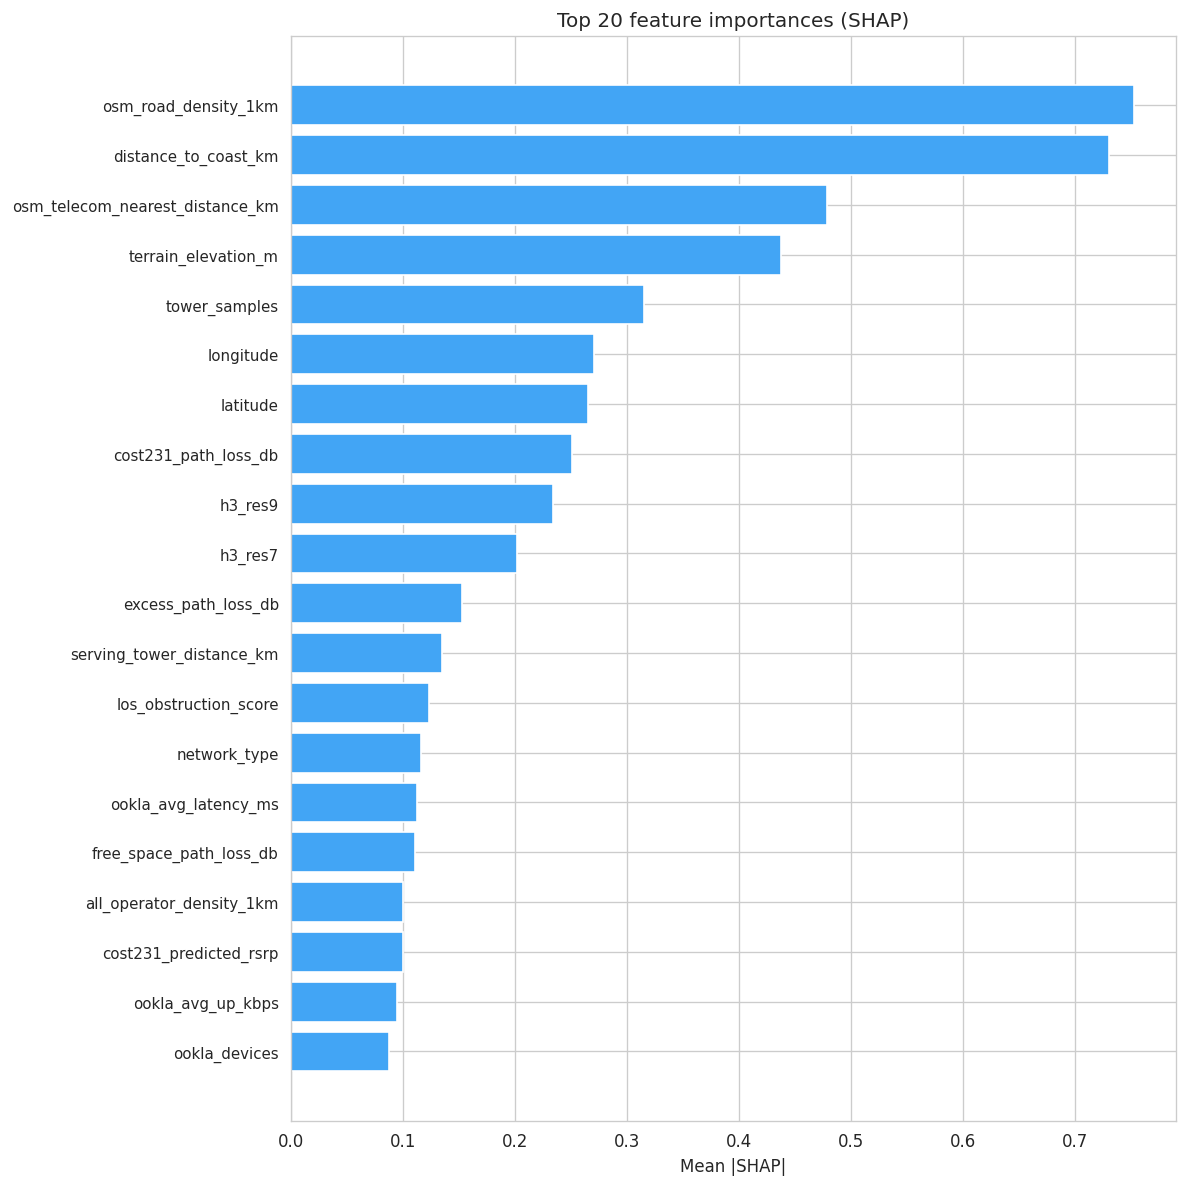

Top 10 most important features:
  1. osm_road_density_1km: 0.7525
  2. distance_to_coast_km: 0.7299
  3. osm_telecom_nearest_distance_km: 0.4787
  4. terrain_elevation_m: 0.4374
  5. tower_samples: 0.3156
  6. longitude: 0.2704
  7. latitude: 0.2657
  8. cost231_path_loss_db: 0.2509
  9. h3_res9: 0.2337
  10. h3_res7: 0.2019


In [24]:
# ──────────────────────────────────────────────────────
# 7a. SHAP values and global feature importance
# ──────────────────────────────────────────────────────
import shap

lgb_clf = classifier.named_steps['cls']
prep = classifier.named_steps['pre']
n_sample = min(500, len(cls_feature_df))
idx_s = np.random.RandomState(42).choice(len(cls_feature_df), n_sample, replace=False)
X_s = prep.transform(cls_feature_df.iloc[idx_s])

explainer = shap.TreeExplainer(lgb_clf)
sv = explainer.shap_values(X_s)
if isinstance(sv, list): sv = sv[1]

# Build feature names from the preprocessor, falling back to the known
# numeric + categorical ordering when ColumnTransformer drops all-NaN cols.
try:
    fnames = list(prep.get_feature_names_out())
except Exception:
    cls_numeric = list(NUMERIC_FEATURES_V3)
    num_trans = prep.named_transformers_['num']
    if hasattr(num_trans, 'statistics_'):
        kept = [f for f, s in zip(cls_numeric, num_trans.statistics_) if not np.isnan(s)]
    else:
        kept = cls_numeric
    fnames = kept + CATEGORICAL_FEATURES_V3

fnames = [f.split('__')[-1] if '__' in f else f for f in fnames]

if sv.shape[1] != len(fnames):
    print(f'Note: SHAP has {sv.shape[1]} features, name list has {len(fnames)}')
    fnames = [f'f{i}' for i in range(sv.shape[1])]

mas = np.abs(sv).mean(axis=0)
si = np.argsort(mas)[::-1]
top = min(20, len(si))

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(range(top), mas[si[:top]][::-1], color='#42A5F5')
ax.set_yticks(range(top))
ax.set_yticklabels([fnames[i] for i in si[:top]][::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP|')
ax.set_title('Top 20 feature importances (SHAP)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'reports' / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
for j in range(min(10, len(si))):
    print(f'  {j+1}. {fnames[si[j]]}: {mas[si[j]]:.4f}')


### 7b. Example predictions with SHAP reasons

Pick a few true-positive and true-negative examples, show the model's probability
plus the top-3 SHAP-based reason strings that will appear in the app UI.


In [25]:
# ──────────────────────────────────────────────────────
# 7b. Example predictions with reasons
# ──────────────────────────────────────────────────────
from deadzone_explain import compute_shap_reasons

examples = []
for val in [1, 0]:
    m = dataset['is_deadzone'] == val
    if m.any(): examples.extend(dataset[m].index[:3].tolist())

# Use the same dynamic feature names from the SHAP cell above
reason_fnames = fnames  # already computed in cell 7a

print('Example Predictions')
print('=' * 65)
for ex_idx in examples:
    pos = dataset.index.get_loc(ex_idx)
    row = cls_feature_df.iloc[pos:pos+1]
    p = classifier.predict_proba(row)[0, 1]
    lat, lon = dataset.loc[ex_idx, 'latitude'], dataset.loc[ex_idx, 'longitude']
    actual = 'DZ' if dataset.loc[ex_idx, 'is_deadzone'] else 'OK'
    lsrc = dataset.loc[ex_idx, 'label_source']
    print(f'\n({lat:.4f}, {lon:.4f}) [{lsrc}] actual={actual} pred={p:.3f}')
    try:
        row_transformed = prep.transform(row)
        reasons = compute_shap_reasons(classifier, row_transformed, reason_fnames, top_k=3)
        for ri, r in enumerate(reasons, 1):
            print(f'  {ri}. {r}')
    except Exception as e:
        print(f'  (reasons unavailable: {e})')
print('\n' + '=' * 65)


Example Predictions

(34.4137, 35.8292) [ookla] actual=DZ pred=0.962
  1. 128 road segments within 1 km (increases risk)
  2. nearest telecom structure 9.26 km away (increases risk)
  3. physics model predicts -87 dBm signal (increases risk)

(34.3956, 35.8347) [ookla] actual=DZ pred=0.962
  1. nearest telecom structure 9.73 km away (increases risk)
  2. 127 road segments within 1 km (increases risk)
  3. h3_res9 = 283.00 (increases risk)

(34.3276, 35.7907) [ookla] actual=DZ pred=0.955
  1. nearest telecom structure 5.96 km away (increases risk)
  2. 39 road segments within 1 km (increases risk)
  3. 5.7 km from coast (increases risk)

(34.4545, 35.8072) [ookla] actual=OK pred=0.000
  1. 0.0 km from coast (decreases risk)
  2. elevation of 1153 m (decreases risk)
  3. nearest telecom structure 10.73 km away (decreases risk)

(34.4545, 35.8127) [ookla] actual=OK pred=0.003
  1. 0.1 km from coast (decreases risk)
  2. h3_res9 = 453.00 (increases risk)
  3. nearest telecom structure 10.2

---
## 8. Export model bundle for deployment

Save a single `.joblib` containing:

- classifier + regressor pipelines (preprocessor + model)
- hyperparameters + spatial-CV metrics
- Berlin transfer metrics + Ookla-agreement metrics
- reference tower subset (for runtime feature computation)
- metadata (training row count, tier counts, bbox, dead-zone rate)

This is the artifact the backend loads at runtime via `predict_deadzone()`.


In [26]:
# ──────────────────────────────────────────────────────
# 8a. Save model bundle
# ──────────────────────────────────────────────────────
import shutil
from deadzone_model import MODEL_VERSION, reference_subset_for_runtime

bundle = {
    'model_version': MODEL_VERSION,
    'trained_at': datetime.now(timezone.utc).isoformat(),
    'model': classifier, 'regressor': regressor,
    'reg_params': reg_params, 'cls_params': cls_params,
    'metrics': metrics,
    'metadata': {
        'training_row_count': len(dataset),
        'tier_counts': dataset['label_source'].value_counts().to_dict(),
        'deadzone_rate': float(dataset['is_deadzone'].mean()),
        'measured_label_pct': float(dataset['label_source'].isin(['app','ookla']).mean()),
        'bbox': BBOX,
    },
    'reference_cells': reference_subset_for_runtime(towers),
    'ookla_tiles': ookla, 'osm_context': osm_telecom,
    'dem_grid': dem, 'osm_buildings': osm_buildings,
    'osm_roads': osm_roads, 'coastline': coastline,
}

model_path = OUTPUT_DIR / 'deadzone_model.joblib'
joblib.dump(bundle, model_path, compress=3)
print(f'Model: {model_path} ({model_path.stat().st_size/1e6:.1f} MB)')

# ── Copy to Google Drive ──
drive_model = DRIVE_OUT / 'deadzone_model.joblib'
shutil.copy2(model_path, drive_model)
print(f'Copied to Drive: {drive_model}')


Model: /content/EECE451-Project/server/instance/ml/deadzone_model.joblib (3.5 MB)
Copied to Drive: /content/drive/MyDrive/EECE451_DeadZone/deadzone_model.joblib


### 8b. Save human-readable report (JSON) + dataset snapshot

Writes `reports/summary.json` with the training metrics, hyperparameters, and
both transfer + agreement evaluation results. Copies everything to Google Drive.


In [27]:
# ──────────────────────────────────────────────────────
# 8b. Save report + dataset
# ──────────────────────────────────────────────────────
report = {
    'trained_at': bundle['trained_at'], 'model_version': MODEL_VERSION,
    'training_rows': len(dataset),
    'deadzone_rate': float(dataset['is_deadzone'].mean()),
    'measured_label_pct': float(dataset['label_source'].isin(['app','ookla']).mean()),
    'metrics': metrics, 'reg_params': reg_params, 'cls_params': cls_params,
    'transfer_metrics_berlin_v2x': transfer_metrics if 'transfer_metrics' in dir() else None,
    'ookla_agreement_lebanon': ookla_metrics if 'ookla_metrics' in dir() else None,
    'tier_counts': dataset['label_source'].value_counts().to_dict(),
}
with open(OUTPUT_DIR / 'reports' / 'summary.json', 'w') as f:
    json.dump(report, f, indent=2, default=str)

dataset.to_csv(OUTPUT_DIR / 'prepared_deadzone_dataset.csv', index=False)
print('Report + dataset saved.')

# ── Copy everything to Google Drive ──
import shutil
for fname in ['summary.json']:
    src = OUTPUT_DIR / 'reports' / fname
    if src.exists(): shutil.copy2(src, DRIVE_OUT / fname)
for fname in ['eda_overview.png', 'eval_plots.png', 'shap_importance.png']:
    src = OUTPUT_DIR / 'reports' / fname
    if src.exists(): shutil.copy2(src, DRIVE_OUT / fname)
shutil.copy2(OUTPUT_DIR / 'prepared_deadzone_dataset.csv',
             DRIVE_OUT / 'prepared_deadzone_dataset.csv')
print(f'All outputs copied to {DRIVE_OUT}')


Report + dataset saved.
All outputs copied to /content/drive/MyDrive/EECE451_DeadZone


### 8c. Inference smoke test

Load the saved bundle and run a prediction at a known Lebanon location
(central Beirut). Confirms the serialized model round-trips correctly.


In [28]:
# ──────────────────────────────────────────────────────
# 8c. Verify inference works
# ──────────────────────────────────────────────────────
from deadzone_model import predict_deadzone

pred = predict_deadzone(
    model_path=str(model_path),
    latitude=33.8938, longitude=35.5018,
    operator='Alfa', network_type='4G',
)

print('Test: Central Beirut (33.8938, 35.5018)')
if pred:
    for k, v in pred.items():
        print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')
    print('\nModel ready for deployment.')


Test: Central Beirut (33.8938, 35.5018)
  predicted_signal_power: -66.2900
  predicted_quality: strong
  deadzone_risk: 0.0001
  deadzone_label: low
  confidence: 0.9999
  training_sample_count: 4701
  nearest_sample_count: 19
  reasons: ['path loss of 107 dB to nearest tower (decreases risk)', '639 buildings within 1 km (decreases risk)', '2 telecom structures within 1 km (decreases risk)']
  model_source: deadzone-model
  model_variant: global

Model ready for deployment.


### 8d. List saved files on Google Drive

Final sanity check — every artifact should now be available at
`/content/drive/MyDrive/EECE451_DeadZone/` for download or re-use.


In [29]:
# ──────────────────────────────────────────────────────
# 8d. List saved files on Google Drive
# ──────────────────────────────────────────────────────
print('\nFiles saved to Google Drive:')
print('=' * 50)
for f in sorted(DRIVE_OUT.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:45s} {size_mb:7.2f} MB')
print(f'\nDrive path: {DRIVE_OUT}')
print('You can download these from Google Drive or use them directly.')


Files saved to Google Drive:
  deadzone_model.joblib                            3.49 MB
  eda_overview.png                                 0.78 MB
  eval_plots.png                                   0.20 MB
  external_data                                    0.00 MB
  prepared_deadzone_dataset.csv                    0.74 MB
  shap_importance.png                              0.10 MB
  summary.json                                     0.00 MB

Drive path: /content/drive/MyDrive/EECE451_DeadZone
You can download these from Google Drive or use them directly.


---
## Summary

| Aspect | Detail |
|--------|--------|
| Models | LightGBM regressor (Huber) + binary classifier |
| Features | 43 primitive features (spatial, topology, propagation, terrain, Ookla, OSM, app) |
| Topology labels | ITU-R P.1812 simplified propagation with Bullington diffraction over SRTM terrain |
| Label fusion | Snorkel-style weak supervision with five independent labeling functions |
| Internal validation | Spatial cross-validation at H3 resolution 5 (approximately 8 km) and a resolution 4 (approximately 25 km) stress test |
| External validation | Berlin V2X (Fraunhofer HHI, CC0) when the parquet is locally available, and a Berlin Ookla cross-city test that always runs |
| Lebanon validation | Ookla agreement on spatial-CV out-of-fold probabilities |
| Explainability | SHAP TreeExplainer with human-readable reasons |
| Thresholds | Speed < 1 Mbps (Falkner et al., arXiv:1804.05771) or RSRP < -110 dBm (3GPP TS 36.133) |

### Interpretation of the honest metrics

Because the app-measurement tier is currently empty, the only tier with real
signal measurements is Ookla speed, which reflects throughput (often limited
by congestion) rather than coverage. The per-tier spatial-CV ROC-AUC near
0.5 on the Ookla tier is expected and reflects that Ookla slowness is a
weak proxy for coverage dead zones. The topology tier, labeled from ITU-R
P.1812 physics and weak-supervision fusion, is the coverage-plausible label;
its held-out AUC is the metric most directly tied to the model's intended
use. The Berlin V2X transfer RMSE remains the cleanest external metric once
the parquet is provided.

### References

1. 3GPP TS 36.133, §9.1.4 — RSRP measurement reporting range
2. Falkner et al., *Performance Evaluation of a Deployed 4G LTE Network*, arXiv:1804.05771
3. Ofcom, *Shared Rural Network Coverage Obligations* (2025)
4. FCC Broadband Speed Benchmark (2010–2024)
5. Apajalahti et al., *Correlation-Based Feature Mapping of Crowdsourced LTE Data*, Aalto (2018)
6. Ratner et al., *Snorkel: Rapid Training Data Creation with Weak Supervision*, VLDB 2017 (arXiv:1711.10160)
7. ITU-R P.1812-6 (2021), point-to-area propagation with terrain diffraction
